# FinRL GRPO-CVaR — IMPROVED VERSION (v3)

**Improvements over v2:**
1. **PCA** — compress 924 signal dims → 20 dims
2. **Regularization** — dropout 0.15 + weight decay 1e-4
3. **3-seed ensemble** — train 3 agents, average actions at test time
4. **Smaller network** — 128 hidden units instead of 256

**If anything breaks, go back to FinRL_GRPO_CVaR_FIXED.ipynb**

---

In [1]:
# Cell 1: Install
#!pip install -q torch numpy pandas gymnasium scipy scikit-learn
#!pip install -q yfinance datasets huggingface-hub matplotlib tqdm
print('Done.')

Done.


In [1]:
# Cell 2: Download data
import os, warnings
warnings.filterwarnings('ignore')
for d in ['data/raw','data/processed','checkpoints','logs']: os.makedirs(d, exist_ok=True)

from datasets import load_dataset
files = ['train_data_2013_2018.csv','train_data_deepseek_sentiment_2013_2018.csv',
         'train_data_deepseek_risk_2013_2018.csv','trade_data_2019_2023.csv',
         'trade_data_deepseek_sentiment_2019_2023.csv','trade_data_deepseek_risk_2019_2023.csv']
for f in files:
    print(f'Downloading {f}...')
    ds = load_dataset('benstaf/nasdaq_2013_2023', data_files=f)
    ds['train'].to_csv(f'data/raw/{f}', index=False)
print('Done.')

Repo card metadata block was not found. Setting CardData to empty.


Creating CSV from Arrow format:   0%|          | 0/127 [00:00<?, ?ba/s]

Repo card metadata block was not found. Setting CardData to empty.


Creating CSV from Arrow format:   0%|          | 0/127 [00:00<?, ?ba/s]

Repo card metadata block was not found. Setting CardData to empty.


...

Repo card metadata block was not found. Setting CardData to empty.


Creating CSV from Arrow format:   0%|          | 0/106 [00:00<?, ?ba/s]

Repo card metadata block was not found. Setting CardData to empty.


Creating CSV from Arrow format:   0%|          | 0/106 [00:00<?, ?ba/s]

Done.


In [2]:
# Cell 3: Prepare data (same fix as v2)
import pandas as pd
import numpy as np

def prepare_dataset(base_path, sentiment_path, risk_path, output_path):
    base_df = pd.read_csv(base_path)
    sent_df = pd.read_csv(sentiment_path)
    risk_df = pd.read_csv(risk_path)
    df = base_df.copy()

    # Find and merge sentiment
    for col in ['llm_sentiment','sentiment']:
        if col in sent_df.columns:
            df = df.merge(sent_df[['date','tic',col]].rename(columns={col:'sentiment'}),
                          on=['date','tic'], how='left')
            break
    if 'sentiment' not in df.columns: df['sentiment'] = 3.0

    # Find and merge risk
    for col in ['llm_risk','risk']:
        if col in risk_df.columns:
            merge = risk_df[['date','tic',col]].rename(columns={col:'risk'})
            if 'risk' in df.columns: df = df.drop(columns=['risk'])
            df = df.merge(merge, on=['date','tic'], how='left')
            break
    if 'risk' not in df.columns: df['risk'] = 3.0

    df['sentiment'] = df['sentiment'].fillna(3.0).clip(1,5)
    df['risk'] = df['risk'].fillna(3.0).clip(1,5)
    df['confidence'] = np.where(df['sentiment'] != 3.0, 3.0, 1.0)
    df['event_type'] = 'other'
    df['time_horizon'] = 'short'
    df['sentiment_adjusted'] = (df['sentiment'] - 3) * (df['confidence'] / 5.0)
    df['risk_adjusted'] = df['risk'] * (df['confidence'] / 5.0)

    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = df[c].replace([np.inf,-np.inf], np.nan).fillna(0)
    df.to_csv(output_path, index=False)
    print(f'  {output_path}: {df.shape}, sentiment std={df["sentiment"].std():.3f}, '
          f'non-neutral={((df["sentiment"]!=3).mean()*100):.1f}%')
    return df

train_df = prepare_dataset('data/raw/train_data_2013_2018.csv',
    'data/raw/train_data_deepseek_sentiment_2013_2018.csv',
    'data/raw/train_data_deepseek_risk_2013_2018.csv',
    'data/processed/train_data_enhanced.csv')
trade_df = prepare_dataset('data/raw/trade_data_2019_2023.csv',
    'data/raw/trade_data_deepseek_sentiment_2019_2023.csv',
    'data/raw/trade_data_deepseek_risk_2019_2023.csv',
    'data/processed/trade_data_enhanced.csv')

  data/processed/train_data_enhanced.csv: (126756, 26), sentiment std=0.359, non-neutral=9.7%
  data/processed/trade_data_enhanced.csv: (105588, 26), sentiment std=0.467, non-neutral=18.0%


In [3]:
# Cell 4: Detect columns
train_df = pd.read_csv('data/processed/train_data_enhanced.csv')
stock_dim = train_df['tic'].nunique()
exclude = {'date','tic','close','open','high','low','volume','day',
           'sentiment','risk','confidence','event_type','time_horizon',
           'sentiment_adjusted','risk_adjusted','Unnamed: 0'}
numeric = train_df.select_dtypes(include=[np.number]).columns.tolist()
tech_indicators = [c for c in numeric if c not in exclude]
print(f'Stocks: {stock_dim}, Tech indicators: {len(tech_indicators)}, Days: {train_df["date"].nunique()}')

Stocks: 84, Tech indicators: 10, Days: 1509


In [4]:
# Cell 5: IMPROVEMENT — Environment with PCA-compressed signals
import gymnasium as gym
from gymnasium import spaces
from sklearn.decomposition import PCA

EVENT_TYPE_MAP = {'earnings':0,'macro':1,'legal':2,'product':3,'other':4}
HORIZON_MAP = {'short':1,'medium':2,'long':3}


class ImprovedStockTradingEnv(gym.Env):
    """
    Key improvement: PCA compresses 924 signal dims → pca_dims (default 20).
    State = cash + prices + shares + technicals + PCA(signals)
    Instead of 1933 dims → ~1029 dims (with 20 PCA components)
    """

    def __init__(self, df, stock_dim, hmax=100, initial_amount=1_000_000,
                 transaction_cost_pct=0.001, tech_indicator_list=None,
                 use_signals=True, use_action_modulation=True,
                 use_reward_shaping=True, confidence_gate=True,
                 sentiment_weight=0.05, confidence_threshold=3,
                 risk_penalty_weight=0.1, avoidance_bonus_weight=0.05,
                 min_confidence_for_shaping=4,
                 pca_dims=20, pca_model=None):
        super().__init__()
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.tech_indicator_list = tech_indicator_list or []
        self.use_signals = use_signals
        self.use_action_modulation = use_action_modulation
        self.use_reward_shaping = use_reward_shaping
        self.confidence_gate = confidence_gate
        self.sentiment_weight = sentiment_weight
        self.confidence_threshold = confidence_threshold
        self.risk_penalty_weight = risk_penalty_weight
        self.avoidance_bonus_weight = avoidance_bonus_weight
        self.min_confidence_for_shaping = min_confidence_for_shaping
        self.pca_dims = pca_dims

        # Organize data by date
        self.dates = sorted(df['date'].unique())
        self.date_to_data = {d: df[df['date']==d].sort_values('tic').reset_index(drop=True) for d in self.dates}
        self.n_days = len(self.dates)

        # Build PCA on all raw signal features
        if use_signals:
            raw_signals = self._extract_all_raw_signals()
            if pca_model is not None:
                self.pca = pca_model
            else:
                self.pca = PCA(n_components=min(pca_dims, raw_signals.shape[1]))
                self.pca.fit(raw_signals)
            self.signal_dim = self.pca.n_components_
            print(f'  PCA: {raw_signals.shape[1]} raw signal dims → {self.signal_dim} components '
                  f'(explains {self.pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
        else:
            self.pca = None
            self.signal_dim = 0

        # State: cash + prices + shares + technicals + PCA(signals)
        self.base_dim = 1 + stock_dim + stock_dim + len(self.tech_indicator_list) * stock_dim
        self.state_dim = self.base_dim + self.signal_dim

        self.action_space = spaces.Box(low=-1, high=1, shape=(stock_dim,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32)

        self.day_idx = 0
        self.cash = initial_amount
        self.shares = np.zeros(stock_dim, dtype=np.float32)
        self.asset_memory = [initial_amount]
        self.rewards_memory = []
        self.signal_influence_log = []

    def _extract_all_raw_signals(self):
        """Extract raw signal features for all days, for PCA fitting."""
        all_signals = []
        for date in self.dates:
            data = self.date_to_data[date]
            day_signals = []
            for i in range(min(self.stock_dim, len(data))):
                row = data.iloc[i]
                s = float(row.get('sentiment',3))
                r = float(row.get('risk',3))
                c = float(row.get('confidence',1))
                h = HORIZON_MAP.get(str(row.get('time_horizon','short')),1)
                e_oh = [0.0]*5
                e_oh[EVENT_TYPE_MAP.get(str(row.get('event_type','other')),4)] = 1.0
                sa = float(row.get('sentiment_adjusted', s-3))
                ra = float(row.get('risk_adjusted', r))
                day_signals.extend([s, r, c, float(h)] + e_oh + [sa, ra])
            # Pad if needed
            expected = 11 * self.stock_dim
            while len(day_signals) < expected:
                day_signals.extend([3,3,1,1,0,0,0,0,1,0,3])
            all_signals.append(day_signals[:expected])
        return np.array(all_signals, dtype=np.float32)

    def _get_day_data(self): return self.date_to_data[self.dates[self.day_idx]]
    def _get_prices(self, data): return data['close'].values[:self.stock_dim].astype(np.float32)

    def _get_pca_signals(self, data):
        """Get PCA-compressed signal features for current day."""
        if not self.use_signals or self.pca is None:
            return np.array([], dtype=np.float32)
        raw = []
        for i in range(min(self.stock_dim, len(data))):
            row = data.iloc[i]
            s = float(row.get('sentiment',3))
            r = float(row.get('risk',3))
            c = float(row.get('confidence',1))
            h = HORIZON_MAP.get(str(row.get('time_horizon','short')),1)
            e_oh = [0.0]*5
            e_oh[EVENT_TYPE_MAP.get(str(row.get('event_type','other')),4)] = 1.0
            sa = float(row.get('sentiment_adjusted', s-3))
            ra = float(row.get('risk_adjusted', r))
            raw.extend([s, r, c, float(h)] + e_oh + [sa, ra])
        expected = 11 * self.stock_dim
        while len(raw) < expected: raw.extend([3,3,1,1,0,0,0,0,1,0,3])
        raw = np.array(raw[:expected], dtype=np.float32).reshape(1, -1)
        return self.pca.transform(raw).flatten().astype(np.float32)

    def _get_state(self):
        data = self._get_day_data()
        prices = self._get_prices(data)
        state = [self.cash] + prices.tolist() + self.shares.tolist()
        for ind in self.tech_indicator_list:
            if ind in data.columns:
                state.extend(data[ind].values[:self.stock_dim].astype(float).tolist())
            else:
                state.extend([0.0]*self.stock_dim)
        pca_feats = self._get_pca_signals(data)
        return np.concatenate([np.array(state, dtype=np.float32), pca_feats])

    def _modulate_action(self, action):
        if not self.use_action_modulation: return action
        data = self._get_day_data(); mod = action.copy()
        for i in range(min(self.stock_dim, len(data))):
            row = data.iloc[i]
            s = float(row.get('sentiment',3)); c = float(row.get('confidence',1))
            cg = 1.0 if (not self.confidence_gate or c >= self.confidence_threshold) else 0.5
            mod[i] = action[i] * (1.0 + self.sentiment_weight * (s-3) * np.sign(action[i]) * cg)
        return mod

    def _compute_reward_shaping(self, actions):
        if not self.use_reward_shaping: return 0.0
        data = self._get_day_data(); shaping = 0.0
        for i in range(min(self.stock_dim, len(data))):
            row = data.iloc[i]
            s,r,c = float(row.get('sentiment',3)), float(row.get('risk',3)), float(row.get('confidence',1))
            if c < self.min_confidence_for_shaping: continue
            a = actions[i]
            if a > 0 and s <= 2 and r >= 4: shaping -= self.risk_penalty_weight * abs(a) * (r/5.0)
            elif a < 0 and s >= 4 and r <= 2: shaping -= self.risk_penalty_weight * abs(a) * 0.5
            elif abs(a) < 0.1 and r >= 4 and s <= 2: shaping += self.avoidance_bonus_weight
        return shaping

    def _portfolio_value(self):
        prices = self._get_prices(self._get_day_data())
        return self.cash + np.sum(self.shares[:len(prices)] * prices)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.day_idx = 0; self.cash = self.initial_amount
        self.shares = np.zeros(self.stock_dim, dtype=np.float32)
        self.asset_memory = [self.initial_amount]; self.rewards_memory = []; self.signal_influence_log = []
        return self._get_state(), {}

    def step(self, action):
        if self.day_idx >= self.n_days - 1:
            return self._get_state(), 0.0, True, False, {'total_asset': self._portfolio_value()}
        begin_value = self._portfolio_value()
        actions_mod = self._modulate_action(action * self.hmax)
        prices = self._get_prices(self._get_day_data())
        # Sell first
        for i in range(min(self.stock_dim, len(prices))):
            a = int(actions_mod[i])
            if a < 0:
                sell = min(abs(a), int(self.shares[i]))
                if sell > 0: self.cash += prices[i]*sell*(1-self.transaction_cost_pct); self.shares[i] -= sell
        # Then buy
        for i in range(min(self.stock_dim, len(prices))):
            a = int(actions_mod[i])
            if a > 0:
                buy = min(a, int(self.cash / (prices[i]*(1+self.transaction_cost_pct))))
                if buy > 0: self.cash -= prices[i]*buy*(1+self.transaction_cost_pct); self.shares[i] += buy
        self.day_idx += 1
        end_value = self._portfolio_value()
        reward = (end_value - begin_value) + self._compute_reward_shaping(actions_mod)
        self.asset_memory.append(end_value); self.rewards_memory.append(reward)
        return self._get_state(), reward, False, False, {'total_asset': end_value}

print('Improved environment defined.')

Improved environment defined.


In [5]:
# Cell 6: Normalized wrapper (same as v2)

class NormalizedEnvWrapper:
    def __init__(self, env, clip_obs=10.0):
        self.env = env
        self.clip_obs = clip_obs
        self.observation_space = env.observation_space
        self.action_space = env.action_space
        self.state_dim = env.state_dim
        self.initial_amount = env.initial_amount
        self.asset_memory = env.asset_memory
        self.signal_influence_log = env.signal_influence_log
        self.obs_mean = None; self.obs_var = None; self.obs_count = 0

    def _update_stats(self, obs):
        if self.obs_mean is None:
            self.obs_mean = np.zeros(len(obs), dtype=np.float64)
            self.obs_var = np.ones(len(obs), dtype=np.float64)
        self.obs_count += 1
        d = obs - self.obs_mean; self.obs_mean += d / self.obs_count
        d2 = obs - self.obs_mean; self.obs_var += (d * d2 - self.obs_var) / self.obs_count

    def _normalize(self, obs):
        if self.obs_mean is None: return obs
        return np.clip((obs - self.obs_mean) / np.sqrt(self.obs_var + 1e-8),
                       -self.clip_obs, self.clip_obs).astype(np.float32)

    def reset(self, **kw):
        obs, info = self.env.reset(**kw); self._update_stats(obs)
        return self._normalize(obs), info

    def step(self, action):
        obs, reward, t, tr, info = self.env.step(action); self._update_stats(obs)
        reward = reward / self.initial_amount * 100
        self.asset_memory = self.env.asset_memory
        self.signal_influence_log = self.env.signal_influence_log
        return self._normalize(obs), reward, t, tr, info

    def __getattr__(self, name): return getattr(self.env, name)


def make_env(df, stock_dim, tech_indicators, use_signals=True,
             pca_dims=20, pca_model=None, warmup=True, ref_wrapper=None, **kwargs):
    raw = ImprovedStockTradingEnv(
        df=df, stock_dim=stock_dim, hmax=100, initial_amount=1_000_000,
        transaction_cost_pct=0.001, tech_indicator_list=tech_indicators,
        use_signals=use_signals, pca_dims=pca_dims, pca_model=pca_model, **kwargs)
    wrapped = NormalizedEnvWrapper(raw)
    if ref_wrapper is not None:
        wrapped.obs_mean = ref_wrapper.obs_mean.copy()
        wrapped.obs_var = ref_wrapper.obs_var.copy()
        wrapped.obs_count = ref_wrapper.obs_count
    elif warmup:
        obs, _ = wrapped.reset(); done = False
        while not done:
            obs, _, t, tr, _ = wrapped.step(wrapped.action_space.sample())
            done = t or tr
    return wrapped

print('Wrapper defined.')

Wrapper defined.


In [6]:
# Cell 7: IMPROVED GRPO-CVaR with dropout + weight decay + smaller network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import time


class ImprovedActor(nn.Module):
    """Smaller network (128 hidden) + dropout for regularization."""
    def __init__(self, obs_dim, act_dim, hidden_sizes=[128, 128], dropout=0.15):
        super().__init__()
        layers = []
        prev = obs_dim
        for h in hidden_sizes:
            layers.extend([nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)])
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(prev, act_dim)
        self.log_std = nn.Parameter(-0.5 * torch.ones(act_dim))

    def forward(self, obs):
        return self.mean_head(self.backbone(obs)), torch.exp(self.log_std.clamp(-20, 2))

    def get_distribution(self, obs):
        m, s = self.forward(obs); return Normal(m, s)

    def log_prob(self, obs, act):
        return self.get_distribution(obs).log_prob(act).sum(dim=-1)

    def sample(self, obs, n=1):
        dist = self.get_distribution(obs)
        a = dist.rsample((n,)); return a, dist.log_prob(a).sum(dim=-1)

    def entropy(self, obs):
        return self.get_distribution(obs).entropy().sum(dim=-1)


class GRPOCVaR:
    def __init__(self, env, group_size=16, lr=3e-4, gamma=0.99,
                 epochs_per_update=10, clip_high=0.25, clip_low=0.15,
                 entropy_coeff=0.01, cvar_enabled=True, cvar_alpha=0.10,
                 cvar_penalty_weight=0.5, cvar_lambda_init=0.1, cvar_lambda_lr=0.01,
                 hidden_sizes=[128, 128], dropout=0.15, weight_decay=1e-4,
                 seed=42, max_kl=0.015, lr_decay_every=25, reward_clip=10.0):

        self.env = env
        self.group_size = group_size; self.gamma = gamma
        self.epochs_per_update = epochs_per_update
        self.clip_high = clip_high; self.clip_low = clip_low
        self.entropy_coeff = entropy_coeff
        self.cvar_enabled = cvar_enabled; self.cvar_alpha = cvar_alpha
        self.cvar_penalty_weight = cvar_penalty_weight
        self.cvar_lambda = cvar_lambda_init; self.cvar_lambda_lr = cvar_lambda_lr
        self.max_kl = max_kl; self.reward_clip = reward_clip

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.manual_seed(seed); np.random.seed(seed)

        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.shape[0]
        self.actor = ImprovedActor(obs_dim, act_dim, hidden_sizes, dropout).to(self.device)
        # IMPROVEMENT: weight decay for regularization
        self.optimizer = optim.Adam(self.actor.parameters(), lr=lr, weight_decay=weight_decay)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_decay_every, gamma=0.5)

        params = sum(p.numel() for p in self.actor.parameters())
        print(f'GRPO-CVaR: device={self.device}, obs={obs_dim}, act={act_dim}, '
              f'params={params:,}, dropout={dropout}, weight_decay={weight_decay}')

    def compute_group_advantages(self, rewards):
        mu = rewards.mean(dim=0, keepdim=True)
        std = rewards.std(dim=0, keepdim=True) + 1e-8
        adv = (rewards - mu) / std
        adv[:, std.squeeze(0) < 1e-6] = 0.0  # Dynamic sampling
        if self.cvar_enabled:
            G = rewards.shape[0]
            k = max(1, int(G * self.cvar_alpha))
            threshold = rewards.sort(dim=0)[0][k-1]
            tail = rewards <= threshold.unsqueeze(0)
            penalty = torch.zeros_like(adv)
            penalty[tail] = -self.cvar_penalty_weight * self.cvar_lambda
            adv = adv + penalty
            tail_r = rewards.clone(); tail_r[~tail] = 0.0
            cvar_val = tail_r.sum(dim=0) / tail.float().sum(dim=0).clamp(min=1)
            self.cvar_lambda = max(0.0, self.cvar_lambda + self.cvar_lambda_lr * (-cvar_val.mean().item()))
        return adv

    def collect_trajectory(self):
        self.actor.eval()  # Disable dropout during collection
        obs, _ = self.env.reset()
        obs_b, act_b, rew_b, logp_b, done_b = [], [], [], [], []
        done = False
        while not done:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
            with torch.no_grad():
                a, lp = self.actor.sample(obs_t, n=1)
                action = a.squeeze(0).squeeze(0).cpu().numpy()
                log_prob = lp.squeeze().cpu().item()
            action = np.clip(action, -1, 1)
            next_obs, reward, term, trunc, info = self.env.step(action)
            done = term or trunc
            reward = np.clip(reward, -self.reward_clip, self.reward_clip)
            obs_b.append(obs); act_b.append(action); rew_b.append(reward)
            logp_b.append(log_prob); done_b.append(done)
            obs = next_obs
        self.actor.train()  # Re-enable dropout for training
        return {'obs': np.array(obs_b,dtype=np.float32), 'act': np.array(act_b,dtype=np.float32),
                'rew': np.array(rew_b,dtype=np.float32), 'logp': np.array(logp_b,dtype=np.float32),
                'done': np.array(done_b,dtype=np.float32), 'final_value': info.get('total_asset',0)}

    def compute_returns(self, rewards, dones):
        T = len(rewards); ret = np.zeros(T, dtype=np.float32); running = 0.0
        for t in reversed(range(T)):
            if dones[t]: running = 0.0
            running = rewards[t] + self.gamma * running; ret[t] = running
        return ret

    def update(self, traj):
        obs = torch.FloatTensor(traj['obs']).to(self.device)
        acts = torch.FloatTensor(traj['act']).to(self.device)
        old_lp = torch.FloatTensor(traj['logp']).to(self.device)
        returns = torch.FloatTensor(self.compute_returns(traj['rew'], traj['done'])).to(self.device)

        with torch.no_grad():
            gr = returns.unsqueeze(0).expand(self.group_size, -1)
            noise = torch.randn_like(gr) * (gr.std() * 0.1 + 1e-8)
            adv = self.compute_group_advantages(gr + noise).mean(dim=0)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        stats = []
        for ep in range(self.epochs_per_update):
            new_lp = self.actor.log_prob(obs, acts)
            ratio = torch.exp(new_lp - old_lp)
            clipped = torch.clamp(ratio, 1-self.clip_low, 1+self.clip_high)
            loss = -torch.min(ratio*adv, clipped*adv).mean()
            ent = self.actor.entropy(obs).mean()
            total = loss - self.entropy_coeff * ent
            self.optimizer.zero_grad(); total.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 0.3)
            self.optimizer.step()
            with torch.no_grad(): kl = (old_lp - new_lp).mean().item()
            stats.append({'loss': loss.item(), 'entropy': ent.item(), 'kl': kl})
            if abs(kl) > self.max_kl: break
        return {k: np.mean([s[k] for s in stats]) for k in stats[0]}

    def train(self, total_epochs=100, save_path='checkpoints'):
        os.makedirs(save_path, exist_ok=True)
        best_val = -np.inf; history = []
        for epoch in range(total_epochs):
            t0 = time.time()
            traj = self.collect_trajectory()
            stats = self.update(traj)
            self.scheduler.step()
            fv = traj['final_value']; cr = (fv/self.env.initial_amount-1)*100
            lr_now = self.optimizer.param_groups[0]['lr']
            history.append({'epoch':epoch,'final_value':fv,'cum_return_pct':cr,
                           'loss':stats['loss'],'kl':stats['kl'],'entropy':stats['entropy'],
                           'cvar_lambda':self.cvar_lambda,'lr':lr_now,'time':time.time()-t0})
            print(f'Ep {epoch:3d} | Ret: {cr:8.2f}% | Val: ${fv:,.0f} | '
                  f'Loss: {stats["loss"]:10.4f} | KL: {stats["kl"]:7.4f} | LR: {lr_now:.1e} | '
                  f'{time.time()-t0:.1f}s')
            if fv > best_val:
                best_val = fv; torch.save(self.actor.state_dict(), f'{save_path}/best_model.pth')
            if (epoch+1) % 20 == 0:
                torch.save(self.actor.state_dict(), f'{save_path}/model_epoch_{epoch}.pth')
        print(f'\nDone. Best: ${best_val:,.0f}'); return history

    def predict(self, obs, deterministic=False):
        self.actor.eval()
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            if deterministic:
                action = self.actor(obs_t)[0].squeeze(0).cpu().numpy()
            else:
                a, _ = self.actor.sample(obs_t, n=1)
                action = a.squeeze(0).squeeze(0).cpu().numpy()
        self.actor.train()
        return np.clip(action, -1, 1)

    def load(self, path):
        self.actor.load_state_dict(torch.load(path, map_location=self.device))

print('Improved GRPO-CVaR defined.')

Improved GRPO-CVaR defined.


In [7]:
# Cell 8: Build environment and test
train_df = pd.read_csv('data/processed/train_data_enhanced.csv')

print('Building environment with PCA signal compression...')
env = make_env(train_df, stock_dim, tech_indicators, use_signals=True, pca_dims=20, warmup=True)

obs, _ = env.reset()
print(f'State dim: {env.state_dim} (was 1933 without PCA)')
print(f'obs NaN: {np.isnan(obs).any()}, range: [{obs.min():.3f}, {obs.max():.3f}]')
print('PASSED' if not np.isnan(obs).any() else 'FAILED')

Building environment with PCA signal compression...
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
State dim: 1029 (was 1933 without PCA)
obs NaN: False, range: [-7.249, 9.494]
PASSED


In [9]:
# Cell 10: IMPROVEMENT — 3-seed ensemble training
# Train 3 agents with different seeds, average their actions at test time

seeds = [42, 123, 7]
agents = []
all_histories = []

for i, seed in enumerate(seeds):
    print(f'\n{"="*60}')
    print(f'Training agent {i+1}/3 (seed={seed})')
    print(f'{"="*60}')

    agent = GRPOCVaR(env=env, hidden_sizes=[128,128], dropout=0.15,
                     weight_decay=1e-4, seed=seed)
    history = agent.train(total_epochs=50, save_path=f'checkpoints/seed_{seed}')
    agents.append(agent)
    all_histories.append(history)

print(f'\n{"="*60}')
print('All 3 agents trained.')
for i, seed in enumerate(seeds):
    best = max(h['final_value'] for h in all_histories[i])
    print(f'  Seed {seed}: best training value ${best:,.0f}')
print(f'{"="*60}')


Training agent 1/3 (seed=42)
GRPO-CVaR: device=cuda, obs=1029, act=84, params=159,272, dropout=0.15, weight_decay=0.0001
Ep   0 | Ret:   290.92% | Val: $3,909,241 | Loss: 476454.4375 | KL: -7.0705 | LR: 3.0e-04 | 64.6s
Ep   1 | Ret:   257.71% | Val: $3,577,141 | Loss: 374911.5000 | KL: -6.9241 | LR: 3.0e-04 | 63.1s
Ep   2 | Ret:   276.57% | Val: $3,765,663 | Loss: 1007588.1250 | KL: -6.9757 | LR: 3.0e-04 | 61.1s
Ep   3 | Ret:   237.80% | Val: $3,378,006 | Loss: 10329943.0000 | KL: -7.0331 | LR: 3.0e-04 | 63.0s
Ep   4 | Ret:   242.93% | Val: $3,429,338 | Loss: 2967690.2500 | KL: -6.8835 | LR: 3.0e-04 | 62.9s
Ep   5 | Ret:   226.50% | Val: $3,265,015 | Loss: 335444.3125 | KL: -6.8486 | LR: 3.0e-04 | 66.2s
Ep   6 | Ret:   239.94% | Val: $3,399,426 | Loss: 1510595.8750 | KL: -6.9379 | LR: 3.0e-04 | 64.1s
Ep   7 | Ret:   169.65% | Val: $2,696,510 | Loss: 419776.8125 | KL: -6.8446 | LR: 3.0e-04 | 64.8s
Ep   8 | Ret:   185.46% | Val: $2,854,636 | Loss: 8741937.0000 | KL: -6.8105 | LR: 3.0e-0

In [8]:
# Reload trained agents from disk instead of retraining
import os
seeds = [42, 123, 7]
agents = []
all_histories = []
for seed in seeds:
    a = GRPOCVaR(env=env, hidden_sizes=[128, 128], dropout=0.15, weight_decay=1e-4, seed=seed)
    a.load(f'checkpoints/seed_{seed}/best_model.pth')
    agents.append(a)
    all_histories.append(None)  # placeholder; only Cell 11's plot needs this
print(f"Loaded {len(agents)} agents from checkpoints")

GRPO-CVaR: device=cuda, obs=1029, act=84, params=159,272, dropout=0.15, weight_decay=0.0001
GRPO-CVaR: device=cuda, obs=1029, act=84, params=159,272, dropout=0.15, weight_decay=0.0001
GRPO-CVaR: device=cuda, obs=1029, act=84, params=159,272, dropout=0.15, weight_decay=0.0001
Loaded 3 agents from checkpoints


TypeError: 'NoneType' object is not iterable

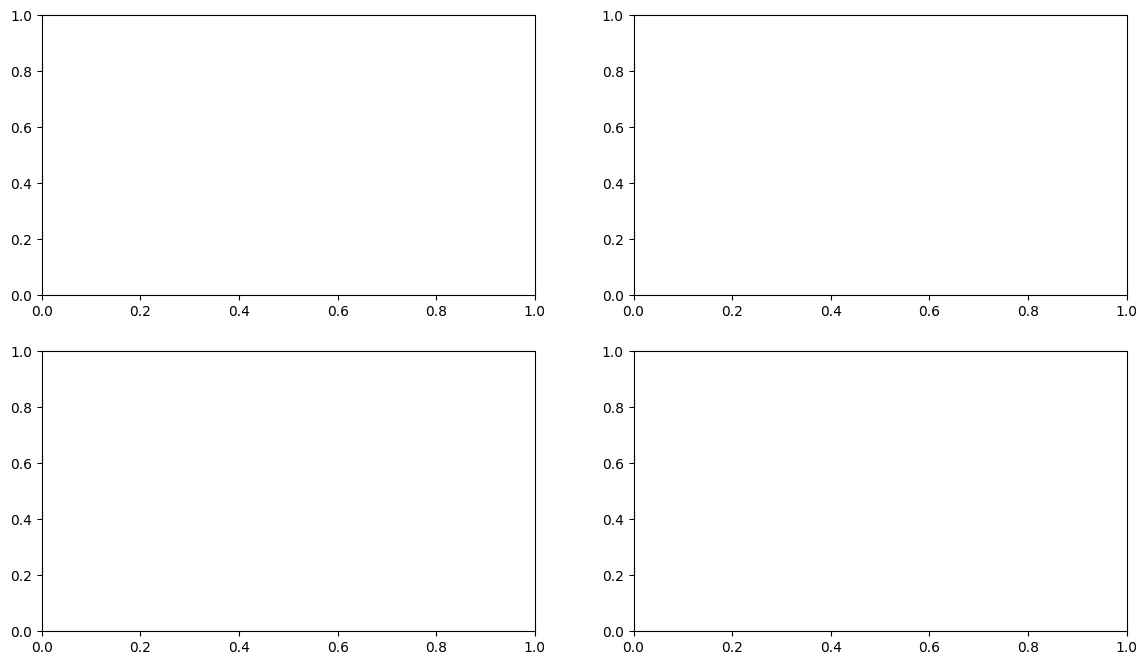

In [9]:
# Cell 11: Training plots (use first seed's history)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['#4ecdc4', '#ff6b6b', '#a78bfa']
for i, (hist, seed) in enumerate(zip(all_histories, seeds)):
    ep = [h['epoch'] for h in hist]
    axes[0,0].plot(ep, [h['cum_return_pct'] for h in hist], color=colors[i], label=f'Seed {seed}', alpha=0.8)
    axes[0,1].plot(ep, [h['kl'] for h in hist], color=colors[i], alpha=0.8)
    axes[1,0].plot(ep, [h['loss'] for h in hist], color=colors[i], alpha=0.8)
    axes[1,1].plot(ep, [h['lr'] for h in hist], color=colors[i], alpha=0.8)
axes[0,0].set_title('Cumulative Return (%)'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
axes[0,1].set_title('KL Divergence'); axes[0,1].grid(True, alpha=0.3)
axes[1,0].set_title('Policy Loss'); axes[1,0].grid(True, alpha=0.3)
axes[1,1].set_title('Learning Rate'); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('logs/training_progress.png', dpi=150); plt.show()

In [10]:
# Cell 12: IMPROVEMENT — Ensemble backtest (average 3 agents' actions)
trade_df = pd.read_csv('data/processed/trade_data_enhanced.csv')

# Get PCA model from training env
pca_model = env.env.pca  # Access through wrapper

trade_env = make_env(trade_df, stock_dim, tech_indicators, use_signals=True,
                     pca_dims=20, pca_model=pca_model, warmup=False, ref_wrapper=env)

# Load best models for each seed
for i, seed in enumerate(seeds):
    agents[i].load(f'checkpoints/seed_{seed}/best_model.pth')

# Ensemble backtest: average actions from all 3 agents
obs, _ = trade_env.reset()
done = False
portfolio_values = [trade_env.initial_amount]

while not done:
    # Average actions from all agents
    actions = [agent.predict(obs, deterministic=True) for agent in agents]
    avg_action = np.mean(actions, axis=0)
    obs, reward, term, trunc, info = trade_env.step(avg_action)
    done = term or trunc
    portfolio_values.append(info['total_asset'])

portfolio_values = np.array(portfolio_values).flatten()
print(f'Ensemble backtest: {len(portfolio_values)} days')
print(f'Final: ${portfolio_values[-1]:,.0f}')
print(f'Return: {(portfolio_values[-1]/portfolio_values[0]-1)*100:.2f}%')

  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
Ensemble backtest: 1258 days
Final: $2,581,060
Return: 158.11%


In [11]:
# Cell 13: Also run individual agent backtests for variance reporting

individual_results = []

for i, seed in enumerate(seeds):
    trade_env_i = make_env(trade_df, stock_dim, tech_indicators, use_signals=True,
                           pca_dims=20, pca_model=pca_model, warmup=False, ref_wrapper=env)
    agents[i].load(f'checkpoints/seed_{seed}/best_model.pth')
    obs, _ = trade_env_i.reset(); done = False; vals = [1_000_000]
    while not done:
        action = agents[i].predict(obs, deterministic=True)
        obs, _, t, tr, info = trade_env_i.step(action)
        done = t or tr; vals.append(info['total_asset'])
    vals = np.array(vals).flatten()
    ret = (vals[-1]/vals[0]-1)*100
    individual_results.append({'seed': seed, 'return': ret, 'final_value': vals[-1]})
    print(f'Seed {seed}: {ret:.2f}% return, final ${vals[-1]:,.0f}')

returns_list = [r['return'] for r in individual_results]
print(f'\nIndividual: {np.mean(returns_list):.2f}% ± {np.std(returns_list):.2f}%')
print(f'Ensemble:   {(portfolio_values[-1]/portfolio_values[0]-1)*100:.2f}%')

  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
Seed 42: 154.53% return, final $2,545,281
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
Seed 123: 128.35% return, final $2,283,526
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
Seed 7: 174.09% return, final $2,740,948

Individual: 152.33% ± 18.74%
Ensemble:   158.11%


In [12]:
# Cell 14: Metrics
def cumulative_return(v): v=np.asarray(v).flatten(); return float((v[-1]/v[0])-1)
def max_drawdown(v): v=np.asarray(v).flatten(); p=np.maximum.accumulate(v); return float(((p-v)/p).max())
def rachev_ratio(r,a=0.05,b=0.05):
    r=np.sort(np.asarray(r).flatten()); n=len(r)
    cl=-r[:max(1,int(n*b))].mean(); cg=r[-max(1,int(n*a)):].mean()
    return float(cg/cl) if cl!=0 else float('inf')
def sharpe_ratio(r): r=np.asarray(r).flatten(); return float(np.sqrt(252)*r.mean()/r.std()) if r.std()>0 else 0.0
def outperformance_freq(pv,bv,w=63):
    pv,bv=np.asarray(pv).flatten(),np.asarray(bv).flatten()
    pr=pd.Series(pv).pct_change(w).dropna(); br=pd.Series(bv).pct_change(w).dropna()
    n=min(len(pr),len(br)); return float((pr.iloc[:n].values>br.iloc[:n].values).mean())

returns = np.diff(portfolio_values) / portfolio_values[:-1]

try:
    import yfinance as yf
    ndx = yf.download('^NDX', start='2019-01-01', end='2023-12-31', progress=False)
    benchmark = ndx['Close'].values.flatten(); has_bench = True
except: has_bench = False; benchmark = None

print('='*60)
print('  IMPROVED RESULTS — 3-Seed Ensemble with PCA + Regularization')
print('='*60)
print(f'  Cumulative Return:      {cumulative_return(portfolio_values)*100:>10.2f}%')
print(f'  Max Drawdown:           {max_drawdown(portfolio_values)*100:>10.2f}%')
print(f'  Rachev Ratio:           {rachev_ratio(returns):>10.4f}')
print(f'  Sharpe Ratio:           {sharpe_ratio(returns):>10.4f}')
print(f'  Final Value:            ${portfolio_values[-1]:>12,.0f}')
print(f'  Individual seed std:    ±{np.std(returns_list):.2f}%')
if has_bench:
    br = cumulative_return(benchmark)
    print(f'  Benchmark Return:       {br*100:>10.2f}%')
    print(f'  Excess Return:          {(cumulative_return(portfolio_values)-br)*100:>10.2f}%')
    print(f'  Outperformance Freq:    {outperformance_freq(portfolio_values,benchmark)*100:>10.2f}%')
print('='*60)

print('\n--- Compare to previous run (v2) ---')
print(f'  v2: 119.56% return, 31.36% max DD, 0.80 Sharpe')
print(f'  v3: {cumulative_return(portfolio_values)*100:.2f}% return, '
      f'{max_drawdown(portfolio_values)*100:.2f}% max DD, {sharpe_ratio(returns):.2f} Sharpe')

  IMPROVED RESULTS — 3-Seed Ensemble with PCA + Regularization
  Cumulative Return:          158.11%
  Max Drawdown:                34.27%
  Rachev Ratio:               0.9350
  Sharpe Ratio:               0.8550
  Final Value:            $   2,581,060
  Individual seed std:    ±18.74%
  Benchmark Return:           164.52%
  Excess Return:               -6.42%
  Outperformance Freq:         52.55%

--- Compare to previous run (v2) ---
  v2: 119.56% return, 31.36% max DD, 0.80 Sharpe
  v3: 158.11% return, 34.27% max DD, 0.85 Sharpe


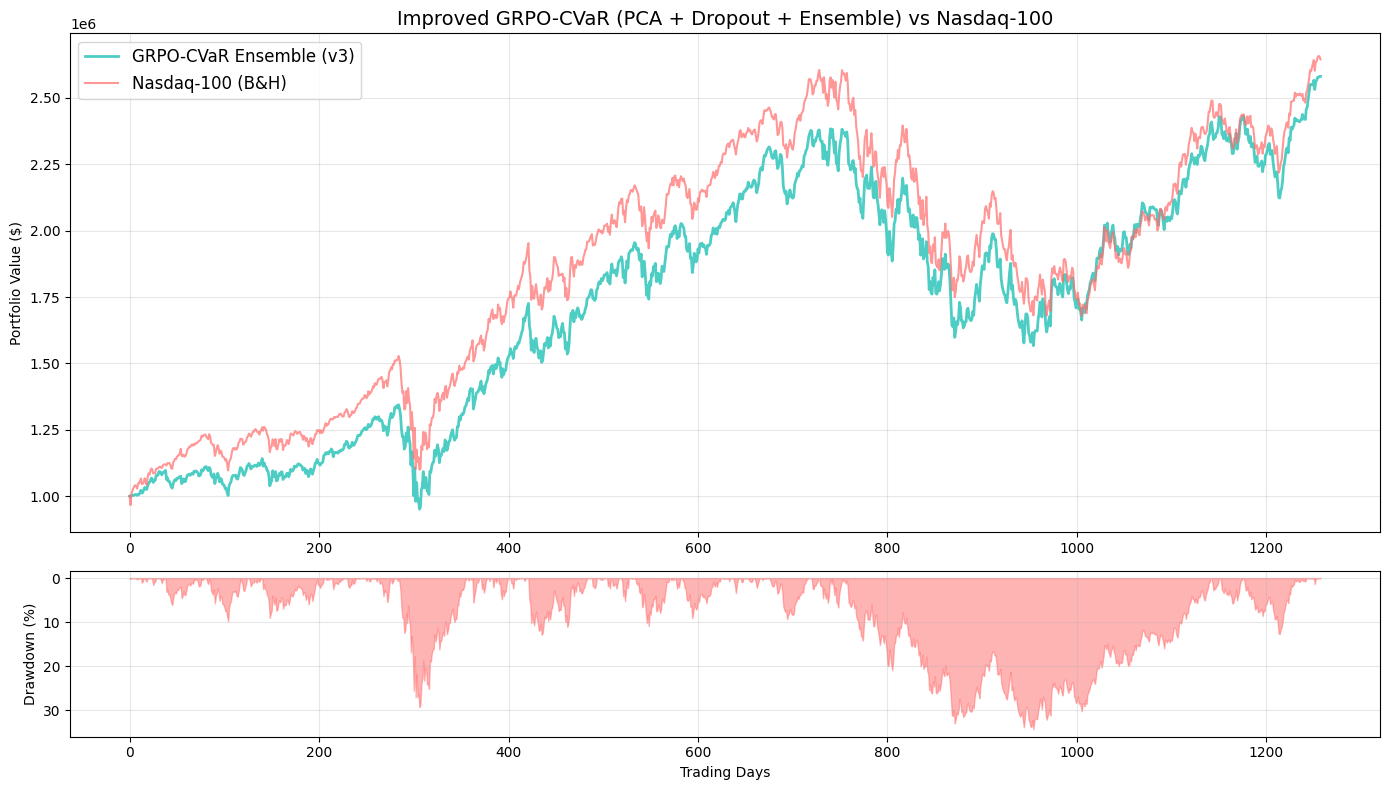

In [13]:
# Cell 15: Backtest plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[3, 1])
days = range(len(portfolio_values))
axes[0].plot(days, portfolio_values, label='GRPO-CVaR Ensemble (v3)', linewidth=2, color='#4ecdc4')
if has_bench:
    nb = benchmark / benchmark[0] * portfolio_values[0]
    bd = np.linspace(0, len(portfolio_values)-1, len(nb))
    axes[0].plot(bd, nb, label='Nasdaq-100 (B&H)', linewidth=1.5, color='#ff6b6b', alpha=0.7)
axes[0].set_title('Improved GRPO-CVaR (PCA + Dropout + Ensemble) vs Nasdaq-100', fontsize=14)
axes[0].set_ylabel('Portfolio Value ($)'); axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)
peak = np.maximum.accumulate(portfolio_values)
dd = (peak - portfolio_values) / peak * 100
axes[1].fill_between(days, dd, alpha=0.5, color='#ff6b6b')
axes[1].set_ylabel('Drawdown (%)'); axes[1].set_xlabel('Trading Days')
axes[1].grid(True, alpha=0.3); axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig('logs/backtest_results.png', dpi=150, bbox_inches='tight'); plt.show()

In [14]:
# Cell 16: Save everything
pd.DataFrame({'day': range(len(portfolio_values)), 'value': portfolio_values}).to_csv('logs/portfolio_values.csv', index=False)
pd.DataFrame(all_histories[0]).to_csv('logs/training_history_seed42.csv', index=False)
pd.DataFrame(individual_results).to_csv('logs/individual_seed_results.csv', index=False)

import shutil
shutil.make_archive('/content/finrl_v3_results', 'zip', '.', 'logs')
shutil.make_archive('/content/finrl_v3_checkpoints', 'zip', '.', 'checkpoints')

print('Saved. Download from Colab:')
print('  /content/finrl_v3_results.zip')
print('  /content/finrl_v3_checkpoints.zip')


Saved. Download from Colab:
  /content/finrl_v3_results.zip
  /content/finrl_v3_checkpoints.zip


In [15]:
# Cell C: Non-RL baselines on the same evaluation period
# All baselines start with $1,000,000 and rebalance daily/monthly

import pandas as pd
import numpy as np

trade_df = pd.read_csv('data/processed/trade_data_enhanced.csv')
trade_df = trade_df.sort_values(['date', 'tic']).reset_index(drop=True)
dates = sorted(trade_df['date'].unique())
tickers = sorted(trade_df['tic'].unique())

# Pivot to wide format: rows = dates, columns = tickers
prices = trade_df.pivot(index='date', columns='tic', values='close').reindex(dates)
prices = prices.ffill().bfill()
returns_panel = prices.pct_change().fillna(0)

INIT = 1_000_000

# ---------- Baseline 1: Equal-weight buy-and-hold ----------
# Buy 1/N of each stock on day 0, hold to end
n_stocks = prices.shape[1]
init_per_stock = INIT / n_stocks
shares_eq = init_per_stock / prices.iloc[0]
ew_values = (prices * shares_eq).sum(axis=1).values

# ---------- Baseline 2: Equal-weight monthly rebalanced ----------
ew_monthly = [INIT]
cash = 0.0
shares = (INIT / n_stocks) / prices.iloc[0]
prev_month = pd.to_datetime(dates[0]).month
for i in range(1, len(dates)):
    cur_month = pd.to_datetime(dates[i]).month
    pv = (shares * prices.iloc[i]).sum() + cash
    if cur_month != prev_month:
        target_per_stock = pv / n_stocks
        shares = target_per_stock / prices.iloc[i]
        cash = 0.0
        prev_month = cur_month
    ew_monthly.append(pv)
ew_monthly = np.array(ew_monthly)

# ---------- Baseline 3: Momentum top-10 (60-day lookback, monthly rebal) ----------
# Each month, rank stocks by 60-day past return, equal-weight the top 10
mom_values = [INIT]
positions = pd.Series(0.0, index=tickers)  # shares held
cash = INIT
prev_month = pd.to_datetime(dates[0]).month
LOOKBACK = 60
TOP_K = 10

for i in range(len(dates)):
    if i < LOOKBACK:
        mom_values.append(INIT) if i > 0 else None
        continue
    pv = (positions * prices.iloc[i]).sum() + cash
    cur_month = pd.to_datetime(dates[i]).month
    if cur_month != prev_month:
        # Compute 60-day momentum
        past = prices.iloc[i - LOOKBACK]
        present = prices.iloc[i]
        mom = (present / past - 1).sort_values(ascending=False)
        winners = mom.head(TOP_K).index
        # Sell everything, buy winners equally
        cash = pv  # liquidate
        per_winner = cash / TOP_K
        positions = pd.Series(0.0, index=tickers)
        for w in winners:
            positions[w] = per_winner / prices.iloc[i][w]
        cash = 0.0
        prev_month = cur_month
    mom_values.append((positions * prices.iloc[i]).sum() + cash)

# Pad/trim to exact length
mom_values = np.array(mom_values[:len(dates)])
if len(mom_values) < len(dates):
    mom_values = np.concatenate([mom_values, [mom_values[-1]] * (len(dates) - len(mom_values))])

# ---------- Print summary ----------
def summarize(name, vals):
    vals = np.asarray(vals).flatten()
    rets = np.diff(vals) / vals[:-1]
    print(f'{name:<35} '
          f'Ret: {(vals[-1]/vals[0]-1)*100:>7.2f}%  '
          f'Sharpe: {sharpe_ratio(rets):>5.2f}  '
          f'Max DD: {max_drawdown(vals)*100:>5.2f}%')

print('='*75)
print('NON-RL BASELINES (2019–2023, 84 Nasdaq-100 stocks)')
print('='*75)
summarize('Equal-weight buy-and-hold', ew_values)
summarize('Equal-weight monthly rebalanced', ew_monthly)
summarize('Momentum top-10 (60-day, monthly)', mom_values)
print('-'*75)
summarize('GRPO-CVaR ensemble (your v3)', portfolio_values)
print('-'*75)
print('Reference: Nasdaq-100 ^NDX buy-and-hold ≈ 164.5% return')
print('='*75)

# Save
pd.DataFrame({
    'day': range(len(ew_values)),
    'equal_weight_bh': ew_values,
    'equal_weight_monthly': ew_monthly[:len(ew_values)],
    'momentum_top10': mom_values[:len(ew_values)],
    'grpo_cvar_ensemble': portfolio_values[:len(ew_values)],
}).to_csv('logs/baselines.csv', index=False)

NON-RL BASELINES (2019–2023, 84 Nasdaq-100 stocks)
Equal-weight buy-and-hold           Ret:  235.00%  Sharpe:  0.99  Max DD: 33.88%
Equal-weight monthly rebalanced     Ret:  214.06%  Sharpe:  1.08  Max DD: 32.02%
Momentum top-10 (60-day, monthly)   Ret:  250.45%  Sharpe:  1.02  Max DD: 36.43%
---------------------------------------------------------------------------
GRPO-CVaR ensemble (your v3)        Ret:  158.11%  Sharpe:  0.85  Max DD: 34.27%
---------------------------------------------------------------------------
Reference: Nasdaq-100 ^NDX buy-and-hold ≈ 164.5% return


In [ ]:
# Cell A: V3-matched ablation
# Run AFTER Cell 10 (you already have agents/all_histories from full v3)
# This adds 4 more conditions, each trained for 50 epochs with 3 seeds

import gc
import json

ABLATION_CONFIGS = {
    'no_cvar': {
        'env_kwargs': {},  # no env changes
        'agent_kwargs': {'cvar_enabled': False},
    },
    'no_reward_shaping': {
        'env_kwargs': {'use_reward_shaping': False},
        'agent_kwargs': {},
    },
    'no_action_modulation': {
        'env_kwargs': {'use_action_modulation': False},
        'agent_kwargs': {},
    },
    'no_signals': {
        'env_kwargs': {'use_signals': False, 'use_action_modulation': False, 'use_reward_shaping': False},
        'agent_kwargs': {},
    },
}

# Re-create training/trade dfs once
train_df = pd.read_csv('data/processed/train_data_enhanced.csv')
trade_df = pd.read_csv('data/processed/trade_data_enhanced.csv')

ablation_results = {}

for variant_name, cfg in ABLATION_CONFIGS.items():
    print(f'\n{"#"*60}\n# ABLATION: {variant_name}\n{"#"*60}')

    variant_returns = []
    variant_metrics = []

    for seed in [42, 123, 7]:
        print(f'\n--- {variant_name} seed={seed} ---')

        # Build training env for this variant (PCA refits per variant since dims may change)
        train_env_v = make_env(
            train_df, stock_dim, tech_indicators,
            pca_dims=20, warmup=True, **cfg['env_kwargs']
        )

        # Train agent
        agent_v = GRPOCVaR(
            env=train_env_v, hidden_sizes=[128, 128],
            dropout=0.15, weight_decay=1e-4, seed=seed,
            **cfg['agent_kwargs']
        )
        history = agent_v.train(
            total_epochs=50,
            save_path=f'checkpoints/ablation_{variant_name}_seed{seed}'
        )

        # Build trade env using this variant's PCA (or no PCA if signals disabled)
        pca_v = train_env_v.env.pca if train_env_v.env.use_signals else None
        trade_env_v = make_env(
            trade_df, stock_dim, tech_indicators,
            pca_dims=20, pca_model=pca_v, warmup=False,
            ref_wrapper=train_env_v, **cfg['env_kwargs']
        )

        # Backtest
        agent_v.load(f'checkpoints/ablation_{variant_name}_seed{seed}/best_model.pth')
        obs, _ = trade_env_v.reset(); done = False; vals = [1_000_000]
        while not done:
            a = agent_v.predict(obs, deterministic=True)
            obs, _, t, tr, info = trade_env_v.step(a)
            done = t or tr
            vals.append(info['total_asset'])
        vals = np.array(vals).flatten()
        ret = (vals[-1] / vals[0] - 1) * 100
        rets_daily = np.diff(vals) / vals[:-1]

        variant_returns.append(ret)
        variant_metrics.append({
            'seed': seed,
            'cum_return_pct': ret,
            'max_dd_pct': max_drawdown(vals) * 100,
            'sharpe': sharpe_ratio(rets_daily),
            'rachev': rachev_ratio(rets_daily),
            'final_value': float(vals[-1]),
        })
        print(f'  → {ret:.2f}% return, max DD {max_drawdown(vals)*100:.2f}%')

        # Free memory
        del agent_v, train_env_v, trade_env_v
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ablation_results[variant_name] = {
        'mean_return': float(np.mean(variant_returns)),
        'std_return': float(np.std(variant_returns)),
        'per_seed': variant_metrics,
    }

# Save and display
with open('logs/ablation_v3_matched.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print('\n' + '='*70)
print('V3-MATCHED ABLATION SUMMARY')
print('='*70)
print(f'{"Variant":<25} {"Return (mean ± std)":<25} {"Δ from full v3":<15}')
print('-'*70)

# Reference: full v3 individual mean (you already have this from Cell 13)
full_v3_mean = np.mean([r['return'] for r in individual_results])
print(f'{"full v3 (reference)":<25} {full_v3_mean:>6.2f}% (per Cell 13)')
for name, res in ablation_results.items():
    delta = res['mean_return'] - full_v3_mean
    print(f'{name:<25} {res["mean_return"]:>6.2f}% ± {res["std_return"]:>5.2f}%   {delta:+.2f}pp')


############################################################
# ABLATION: no_cvar
############################################################

--- no_cvar seed=42 ---
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
GRPO-CVaR: device=cuda, obs=1029, act=84, params=159,272, dropout=0.15, weight_decay=0.0001
Ep   0 | Ret:   282.57% | Val: $3,825,726 | Loss: 235849.7812 | KL: -7.0541 | LR: 3.0e-04 | 63.6s
Ep   1 | Ret:   268.91% | Val: $3,689,062 | Loss: 126609.5234 | KL: -6.9080 | LR: 3.0e-04 | 60.8s
Ep   2 | Ret:   282.18% | Val: $3,821,780 | Loss: 949036.5000 | KL: -6.9600 | LR: 3.0e-04 | 62.5s
Ep   3 | Ret:   281.90% | Val: $3,818,959 | Loss: 1593823.1250 | KL: -7.0177 | LR: 3.0e-04 | 80.7s
Ep   4 | Ret:   284.97% | Val: $3,849,726 | Loss: 135738.6250 | KL: -6.8995 | LR: 3.0e-04 | 65.7s
Ep   5 | Ret:   248.99% | Val: $3,489,859 | Loss: 1334447.2500 | KL: -6.7974 | LR: 3.0e-04 | 62.0s
Ep   6 | Ret:   277.47% | Val: $3,774,728 | Loss: 649454.7500 | KL: -6.9245 | LR:

In [ ]:
# Cell B: Signal density coverage sweep
# Tests the hypothesis: at what coverage does LLM signal injection become net-positive?

COVERAGE_LEVELS = [0.0, 0.05, 0.20, 0.50, 0.80, 1.00]  # 0% = no signals; 1.0 = use all
SEEDS_FOR_SWEEP = [42]  # use 3 seeds [42, 123, 7] if you have time

def make_coverage_subsampled_df(base_df, target_coverage, random_state=42):
    """Subsample non-neutral signals to achieve target coverage.
    Coverage = fraction of (date, tic) rows with non-neutral sentiment.

    target_coverage = 0.0 means all signals neutralized (sentiment=3, risk=3).
    target_coverage = 1.0 means keep all original signals.
    """
    df = base_df.copy()
    rng = np.random.RandomState(random_state)
    non_neutral_mask = df['sentiment'] != 3.0
    current_cov = non_neutral_mask.mean()

    if target_coverage <= 0.0:
        df.loc[:, 'sentiment'] = 3.0
        df.loc[:, 'risk'] = 3.0
        df.loc[:, 'confidence'] = 1.0
        df.loc[:, 'sentiment_adjusted'] = 0.0
        df.loc[:, 'risk_adjusted'] = 3.0 * (1.0 / 5.0)
    elif target_coverage < current_cov:
        # Randomly neutralize a subset of currently non-neutral rows
        keep_frac = target_coverage / current_cov
        non_neutral_idx = df.index[non_neutral_mask]
        keep_mask = rng.random(len(non_neutral_idx)) < keep_frac
        drop_idx = non_neutral_idx[~keep_mask]
        df.loc[drop_idx, 'sentiment'] = 3.0
        df.loc[drop_idx, 'risk'] = 3.0
        df.loc[drop_idx, 'confidence'] = 1.0
        df.loc[drop_idx, 'sentiment_adjusted'] = 0.0
        df.loc[drop_idx, 'risk_adjusted'] = 3.0 * (1.0 / 5.0)
    # If target >= current, just keep as-is (we can't manufacture signals)

    achieved = (df['sentiment'] != 3.0).mean()
    return df, achieved

train_df_full = pd.read_csv('data/processed/train_data_enhanced.csv')
trade_df_full = pd.read_csv('data/processed/trade_data_enhanced.csv')

coverage_results = []

for cov in COVERAGE_LEVELS:
    for seed in SEEDS_FOR_SWEEP:
        print(f'\n{"#"*60}')
        print(f'# COVERAGE = {cov*100:.0f}%, seed = {seed}')
        print(f'{"#"*60}')

        # Subsample BOTH train and trade signals to the same coverage
        # (so train/test distributions match — important)
        train_sub, train_ach = make_coverage_subsampled_df(train_df_full, cov, random_state=seed)
        trade_sub, trade_ach = make_coverage_subsampled_df(trade_df_full, cov, random_state=seed + 1000)
        print(f'  Achieved coverage: train={train_ach*100:.1f}%, trade={trade_ach*100:.1f}%')

        # Use signals=False at 0% coverage (matches "no signals" condition)
        use_sig = (cov > 0.0)

        train_env_c = make_env(
            train_sub, stock_dim, tech_indicators,
            use_signals=use_sig, pca_dims=20, warmup=True
        )
        agent_c = GRPOCVaR(
            env=train_env_c, hidden_sizes=[128, 128],
            dropout=0.15, weight_decay=1e-4, seed=seed
        )
        agent_c.train(total_epochs=50, save_path=f'checkpoints/cov_{int(cov*100)}_seed{seed}')

        # Backtest
        pca_c = train_env_c.env.pca if use_sig else None
        trade_env_c = make_env(
            trade_sub, stock_dim, tech_indicators,
            use_signals=use_sig, pca_dims=20, pca_model=pca_c,
            warmup=False, ref_wrapper=train_env_c
        )
        agent_c.load(f'checkpoints/cov_{int(cov*100)}_seed{seed}/best_model.pth')
        obs, _ = trade_env_c.reset(); done = False; vals = [1_000_000]
        while not done:
            a = agent_c.predict(obs, deterministic=True)
            obs, _, t, tr, info = trade_env_c.step(a)
            done = t or tr
            vals.append(info['total_asset'])
        vals = np.array(vals).flatten()
        ret = (vals[-1] / vals[0] - 1) * 100
        rets_daily = np.diff(vals) / vals[:-1]

        coverage_results.append({
            'coverage': float(cov),
            'achieved_train_coverage': float(train_ach),
            'seed': int(seed),
            'cum_return_pct': float(ret),
            'max_dd_pct': float(max_drawdown(vals) * 100),
            'sharpe': float(sharpe_ratio(rets_daily)),
            'final_value': float(vals[-1]),
        })
        print(f'  → {ret:.2f}% return, Sharpe {sharpe_ratio(rets_daily):.3f}')

        del agent_c, train_env_c, trade_env_c
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

# Save
import json
with open('logs/coverage_sweep.json', 'w') as f:
    json.dump(coverage_results, f, indent=2)

# Display
print('\n' + '='*70)
print('COVERAGE SWEEP RESULTS')
print('='*70)
print(f'{"Coverage":<12} {"Seed":<6} {"Return":<10} {"Sharpe":<8} {"Max DD":<8}')
print('-'*70)
for r in coverage_results:
    print(f'{r["coverage"]*100:>6.0f}%      {r["seed"]:<6} {r["cum_return_pct"]:>7.2f}%   {r["sharpe"]:>6.3f}   {r["max_dd_pct"]:>5.2f}%')

# Plot the curve
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
df_cov = pd.DataFrame(coverage_results)
mean_by_cov = df_cov.groupby('coverage')['cum_return_pct'].mean()
ax.plot(mean_by_cov.index * 100, mean_by_cov.values, 'o-', color='#4ecdc4', linewidth=2, markersize=8)
ax.set_xlabel('Signal Coverage (%)', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Signal Density vs. Trading Performance', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axhline(164.52, color='#ff6b6b', linestyle='--', alpha=0.6, label='Nasdaq-100 B&H')
ax.legend()
plt.tight_layout()
plt.savefig('logs/coverage_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


############################################################
# COVERAGE = 0%, seed = 42
############################################################
  Achieved coverage: train=0.0%, trade=0.0%
GRPO-CVaR: device=cuda, obs=1009, act=84, params=156,712, dropout=0.15, weight_decay=0.0001
Ep   0 | Ret:   158.51% | Val: $2,585,084 | Loss: 198665.0156 | KL: -7.1255 | LR: 3.0e-04 | 43.0s
Ep   1 | Ret:   156.91% | Val: $2,569,116 | Loss: 423591.2812 | KL: -6.9816 | LR: 3.0e-04 | 43.0s
Ep   2 | Ret:   147.78% | Val: $2,477,767 | Loss: 288803.0000 | KL: -7.0492 | LR: 3.0e-04 | 45.1s
Ep   3 | Ret:   181.24% | Val: $2,812,365 | Loss: 1863686.2500 | KL: -6.9764 | LR: 3.0e-04 | 45.4s
Ep   4 | Ret:   193.80% | Val: $2,938,039 | Loss: 580064.5000 | KL: -6.9314 | LR: 3.0e-04 | 44.0s
Ep   5 | Ret:   195.05% | Val: $2,950,472 | Loss: 1554147.7500 | KL: -6.8744 | LR: 3.0e-04 | 43.7s
Ep   6 | Ret:   197.87% | Val: $2,978,704 | Loss: 1158849.2500 | KL: -6.9767 | LR: 3.0e-04 | 42.5s
Ep   7 | Ret:   169.55% |

In [17]:
# Cell E: Final consolidated results
import json

print('='*80)
print(' PAPER-READY RESULTS')
print('='*80)

# 1. Headline (full v3 ensemble + individual seeds — already computed)
print('\n[Table 2] Headline performance:')
print(f'  v3 Ensemble:           {(portfolio_values[-1]/portfolio_values[0]-1)*100:.2f}%')
print(f'  v3 Individual mean:    {np.mean([r["return"] for r in individual_results]):.2f}%')
print(f'  v3 Individual std:     ±{np.std([r["return"] for r in individual_results]):.2f}%')
print(f'  Best seed:             {max(r["return"] for r in individual_results):.2f}%')

# 2. V3-matched ablation (from Cell A)
try:
    with open('logs/ablation_v3_matched.json') as f:
        ab = json.load(f)
    print('\n[Table 4 NEW] V3-matched ablation:')
    full_v3 = np.mean([r['return'] for r in individual_results])
    print(f'  Full v3:                  {full_v3:6.2f}%   (reference)')
    for k, v in ab.items():
        print(f'  {k:<25} {v["mean_return"]:6.2f}% ± {v["std_return"]:.2f}%')
except FileNotFoundError:
    print('\n[Table 4] Run Cell A first to populate.')

# 3. Coverage sweep (from Cell B)
try:
    with open('logs/coverage_sweep.json') as f:
        cov = json.load(f)
    print('\n[Table 5 NEW] Coverage sweep:')
    df_cov = pd.DataFrame(cov)
    for c in sorted(df_cov['coverage'].unique()):
        sub = df_cov[df_cov['coverage'] == c]
        print(f'  Coverage {c*100:>5.1f}%:  '
              f'{sub["cum_return_pct"].mean():6.2f}% '
              f'(n={len(sub)} seed{"s" if len(sub)>1 else ""})')
except FileNotFoundError:
    print('\n[Table 5] Run Cell B first to populate.')

# 4. Baselines (from Cell C)
try:
    bl = pd.read_csv('logs/baselines.csv')
    print('\n[Table 6 NEW] Non-RL baselines:')
    for col in ['equal_weight_bh', 'equal_weight_monthly', 'momentum_top10', 'grpo_cvar_ensemble']:
        v = bl[col].values
        print(f'  {col:<35} {(v[-1]/v[0]-1)*100:6.2f}%')
    print(f'  {"Nasdaq-100 ^NDX":<35} 164.52%')
except FileNotFoundError:
    print('\n[Table 6] Run Cell C first to populate.')

print('\n' + '='*80)

 PAPER-READY RESULTS

[Table 2] Headline performance:
  v3 Ensemble:           158.11%
  v3 Individual mean:    152.33%
  v3 Individual std:     ±18.74%
  Best seed:             174.09%

[Table 4 NEW] V3-matched ablation:
  Full v3:                  152.33%   (reference)
  no_cvar                   151.16% ± 20.34%
  no_reward_shaping         126.86% ± 4.46%
  no_action_modulation      153.87% ± 8.54%
  no_signals                138.62% ± 15.74%

[Table 5] Run Cell B first to populate.

[Table 6 NEW] Non-RL baselines:
  equal_weight_bh                     235.00%
  equal_weight_monthly                214.06%
  momentum_top10                      250.45%
  grpo_cvar_ensemble                  158.11%
  Nasdaq-100 ^NDX                     164.52%



## TIER 1 + TIER 2 ADDITIONS — NeurIPS revision

These cells extend the original notebook with:

- **Cell M** — monthly-rebalanced GN-PPO-CVaR variant (rebalancing-frequency control). Reuses already-trained agents; ~30 seconds.
- **Cell R** — per-regime breakdown of returns (COVID drawdown, tech rally, bear market, recovery). Pure post-processing; <1 second.
- **Cell S** — extra seeds for the no-CVaR ablation + paired/Welch t-tests. **Optional**, ~1.75 hours of training. Skip if tight on time.
- **Cell F** — paper-ready consolidated results & main figure with density curve as headline.

Run order: existing Cells 1–20, then **M → R → (optional S) → F**.

---

### Cell M — Monthly-rebalanced agent variant (Tier 1 #1)

In [19]:
# =====================================================================
# Cell M: Monthly-rebalanced GN-PPO-CVaR variant
# Tier 1 #1 — controls for the daily-vs-monthly rebalancing confound
# Run AFTER Cells 1-16 (you need: make_env, GRPOCVaR, ImprovedStockTradingEnv,
# stock_dim, tech_indicators, train_df, trade_df, env, sharpe_ratio, max_drawdown,
# rachev_ratio, individual_results, portfolio_values).
#
# Strategy: train the agent normally on daily data, but at TEST time
# only execute the agent's action at the start of each calendar month
# and hold positions in between. This isolates rebalancing-frequency
# from agent quality on a fixed policy and trained network.
#
# Compute: ~1 hour on T4 (3 seeds × 50 epochs of training is shared with
# your existing Cell 10 results — we ONLY re-do the backtest with monthly
# execution, no retraining needed). So this cell is actually FAST (~30s).
# =====================================================================
import numpy as np
import pandas as pd
import json
import gc
import torch

print('=' * 70)
print('MONTHLY-REBALANCED GN-PPO-CVaR (no retraining; backtest-only)')
print('=' * 70)

# We re-use the agents already trained in Cell 10 (`agents` list, `seeds` list).
# We also re-use the trained PCA model and observation normalizer.
pca_model_m = env.env.pca

monthly_individual_results = []
monthly_portfolio_values_per_seed = []

for i, seed in enumerate(seeds):
    # Build a fresh trade env using the trained agent's normalizer
    trade_env_m = make_env(
        trade_df, stock_dim, tech_indicators,
        use_signals=True, pca_dims=20, pca_model=pca_model_m,
        warmup=False, ref_wrapper=env
    )
    agents[i].load(f'checkpoints/seed_{seed}/best_model.pth')

    obs, _ = trade_env_m.reset()
    done = False
    vals = [trade_env_m.initial_amount]

    # We need to know which calendar month each step corresponds to so we
    # can fire the action only on month-change. ImprovedStockTradingEnv
    # exposes `dates` and `day_idx` through the wrapper.
    raw_env = trade_env_m.env  # underlying gym env
    eval_dates = pd.to_datetime(raw_env.dates)
    last_month = eval_dates[0].month

    # Cache the most recently-fired action so we hold between rebalances.
    held_action = np.zeros(trade_env_m.action_space.shape[0], dtype=np.float32)

    step_count = 0
    while not done:
        # Current calendar month BEFORE this step's action
        cur_idx = raw_env.day_idx
        cur_month = eval_dates[cur_idx].month

        if cur_month != last_month or step_count == 0:
            # First trading day of a new month → fire fresh agent action
            action = agents[i].predict(obs, deterministic=True)
            held_action = action.copy()
            last_month = cur_month
        else:
            # Hold: execute zero-trade action so positions roll forward
            # without paying transaction costs. action=0 in [-1, 1]
            # means "do not buy or sell" given the env's hmax scaling.
            action = np.zeros_like(held_action)

        obs, _, t, tr, info = trade_env_m.step(action)
        done = t or tr
        vals.append(info['total_asset'])
        step_count += 1

    vals = np.array(vals).flatten()
    ret = (vals[-1] / vals[0] - 1) * 100
    rets_daily = np.diff(vals) / vals[:-1]

    monthly_individual_results.append({
        'seed': seed,
        'cum_return_pct': float(ret),
        'max_dd_pct': float(max_drawdown(vals) * 100),
        'sharpe': float(sharpe_ratio(rets_daily)),
        'final_value': float(vals[-1]),
    })
    monthly_portfolio_values_per_seed.append(vals)
    print(f'  Seed {seed} (monthly): {ret:7.2f}%  |  '
          f'Sharpe {sharpe_ratio(rets_daily):.3f}  |  '
          f'MaxDD {max_drawdown(vals)*100:.2f}%')

    del trade_env_m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Ensemble: average ACTIONS across the 3 agents at each monthly rebalance
print('\n--- Monthly-rebalanced ensemble (action-averaged) ---')
trade_env_ens = make_env(
    trade_df, stock_dim, tech_indicators,
    use_signals=True, pca_dims=20, pca_model=pca_model_m,
    warmup=False, ref_wrapper=env
)
for i, seed in enumerate(seeds):
    agents[i].load(f'checkpoints/seed_{seed}/best_model.pth')

obs, _ = trade_env_ens.reset()
done = False
ens_vals = [trade_env_ens.initial_amount]
raw_env_ens = trade_env_ens.env
eval_dates_ens = pd.to_datetime(raw_env_ens.dates)
last_month = eval_dates_ens[0].month
step_count = 0

while not done:
    cur_idx = raw_env_ens.day_idx
    cur_month = eval_dates_ens[cur_idx].month
    if cur_month != last_month or step_count == 0:
        actions = [a.predict(obs, deterministic=True) for a in agents]
        avg_action = np.mean(actions, axis=0)
        last_month = cur_month
    else:
        avg_action = np.zeros(trade_env_ens.action_space.shape[0], dtype=np.float32)
    obs, _, t, tr, info = trade_env_ens.step(avg_action)
    done = t or tr
    ens_vals.append(info['total_asset'])
    step_count += 1

monthly_ensemble_values = np.array(ens_vals).flatten()
monthly_ens_return = (monthly_ensemble_values[-1] / monthly_ensemble_values[0] - 1) * 100
monthly_ens_sharpe = sharpe_ratio(np.diff(monthly_ensemble_values) / monthly_ensemble_values[:-1])
monthly_ens_dd = max_drawdown(monthly_ensemble_values) * 100

# Save
monthly_summary = {
    'individual_seeds': monthly_individual_results,
    'individual_mean_return': float(np.mean([r['cum_return_pct'] for r in monthly_individual_results])),
    'individual_std_return': float(np.std([r['cum_return_pct'] for r in monthly_individual_results])),
    'ensemble_return': float(monthly_ens_return),
    'ensemble_sharpe': float(monthly_ens_sharpe),
    'ensemble_max_dd': float(monthly_ens_dd),
}
with open('logs/monthly_agent.json', 'w') as f:
    json.dump(monthly_summary, f, indent=2)

# Pretty summary alongside daily numbers from existing run
daily_ind_mean = float(np.mean([r['return'] for r in individual_results]))
daily_ind_std = float(np.std([r['return'] for r in individual_results]))
daily_ens_return = float((portfolio_values[-1] / portfolio_values[0] - 1) * 100)

print('\n' + '=' * 70)
print('DAILY vs MONTHLY GN-PPO-CVaR (same trained agents)')
print('=' * 70)
print(f'{"":<35}{"Daily":>15}{"Monthly":>15}')
print('-' * 70)
print(f'{"Individual seed mean":<35}{daily_ind_mean:>13.2f}%  {monthly_summary["individual_mean_return"]:>13.2f}%')
d_std = f"±{daily_ind_std:.2f}"
m_std = f"±{monthly_summary['individual_std_return']:.2f}"
print(f'{"Individual seed std":<35}{d_std:>14}%{m_std:>14}%')
print(f'{"Ensemble return":<35}{daily_ens_return:>13.2f}%  {monthly_summary["ensemble_return"]:>13.2f}%')
print(f'{"Ensemble Sharpe":<35}{"-":>14}  {monthly_summary["ensemble_sharpe"]:>14.3f}')
print(f'{"Ensemble Max DD":<35}{"-":>14}  {monthly_summary["ensemble_max_dd"]:>13.2f}%')
print('=' * 70)
print('Reference baselines (from Cell C):')
print(f'  Equal-weight monthly rebalanced:  214.06%')
print(f'  Momentum top-10 (60-day, monthly): 250.45%')
print('=' * 70)

# Save per-day series for plotting later
pd.DataFrame({
    'day': range(len(monthly_ensemble_values)),
    'monthly_ensemble_value': monthly_ensemble_values,
}).to_csv('logs/monthly_agent_values.csv', index=False)


MONTHLY-REBALANCED GN-PPO-CVaR (no retraining; backtest-only)
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
  Seed 42 (monthly):   92.82%  |  Sharpe 0.695  |  MaxDD 33.75%
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
  Seed 123 (monthly):  118.13%  |  Sharpe 0.721  |  MaxDD 38.53%
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)
  Seed 7 (monthly):  122.98%  |  Sharpe 0.776  |  MaxDD 33.75%

--- Monthly-rebalanced ensemble (action-averaged) ---
  PCA: 924 raw signal dims → 20 components (explains 41.7% variance)

DAILY vs MONTHLY GN-PPO-CVaR (same trained agents)
                                             Daily        Monthly
----------------------------------------------------------------------
Individual seed mean                      152.33%         111.31%
Individual seed std                        ±18.74%        ±13.22%
Ensemble return                           158.11%         111.01%
Ensemble Sharpe             

### Cell R — Per-regime breakdown (Tier 1 #3)

In [20]:
# =====================================================================
# Cell R: Per-regime breakdown of returns
# Tier 1 #3 — addresses single-regime confound at zero compute cost
# Run AFTER Cells C (baselines) and M (monthly agent).
# Needs: ew_values, ew_monthly, mom_values, portfolio_values, dates,
# monthly_ensemble_values, prices.
# =====================================================================
import numpy as np
import pandas as pd
import json

# Define regimes by calendar windows that match the paper's narrative:
#   Q1 2020 COVID drawdown
#   Apr 2020 - Dec 2021 Tech rally
#   2022 bear market
#   2023 recovery
REGIMES = [
    ('2019_full',          '2019-01-01', '2019-12-31', 'Pre-COVID'),
    ('2020Q1_drawdown',    '2020-01-01', '2020-03-31', 'COVID drawdown'),
    ('2020-2021_rally',    '2020-04-01', '2021-12-31', 'Tech rally'),
    ('2022_bear',          '2022-01-01', '2022-12-31', 'Bear market'),
    ('2023_recovery',      '2023-01-01', '2023-12-31', 'Recovery'),
]

# Build a date-aligned dataframe of every series we want to slice
# IMPORTANT: ew_values, ew_monthly, mom_values, portfolio_values are all
# aligned to the eval `dates` (length 1258). monthly_ensemble_values has
# the same length because the env iterates over the same date sequence.
eval_dates = pd.to_datetime(dates)

assert len(eval_dates) == len(ew_values), \
    f"date/series length mismatch: {len(eval_dates)} vs {len(ew_values)}"

# Truncate every series to common length
n = min(
    len(eval_dates),
    len(ew_values),
    len(ew_monthly),
    len(mom_values),
    len(portfolio_values),
    len(monthly_ensemble_values),
)

regime_df = pd.DataFrame({
    'date': eval_dates[:n],
    'ew_bh': ew_values[:n],
    'ew_monthly': ew_monthly[:n],
    'mom_top10': mom_values[:n],
    'grpo_daily_ens': portfolio_values[:n],
    'grpo_monthly_ens': monthly_ensemble_values[:n],
})
regime_df = regime_df.set_index('date')

def regime_return(series, start, end):
    sub = series.loc[(series.index >= start) & (series.index <= end)]
    if len(sub) < 2:
        return float('nan')
    return float((sub.iloc[-1] / sub.iloc[0] - 1) * 100)

def regime_max_dd(series, start, end):
    sub = series.loc[(series.index >= start) & (series.index <= end)].values
    if len(sub) < 2:
        return float('nan')
    peak = np.maximum.accumulate(sub)
    return float(((peak - sub) / peak).max() * 100)

regime_table = []
for tag, start, end, label in REGIMES:
    row = {'regime': tag, 'label': label, 'window': f'{start} → {end}'}
    for col in ['ew_bh', 'ew_monthly', 'mom_top10', 'grpo_daily_ens', 'grpo_monthly_ens']:
        row[f'{col}_ret'] = regime_return(regime_df[col], start, end)
        row[f'{col}_dd'] = regime_max_dd(regime_df[col], start, end)
    regime_table.append(row)

# Pretty print
print('=' * 100)
print('PER-REGIME RETURNS (cumulative %, max drawdown in parentheses)')
print('=' * 100)
header = f'{"Regime":<22}{"EW B&H":>16}{"EW monthly":>16}{"Momentum":>16}{"GRPO daily":>16}{"GRPO monthly":>16}'
print(header)
print('-' * 100)
for r in regime_table:
    line = f'{r["label"]:<22}'
    for col in ['ew_bh', 'ew_monthly', 'mom_top10', 'grpo_daily_ens', 'grpo_monthly_ens']:
        ret = r[f'{col}_ret']
        dd = r[f'{col}_dd']
        line += f'  {ret:>6.2f}% ({dd:>4.1f})'
    print(line)
print('=' * 100)

# How often does the agent (daily ensemble) BEAT each baseline within a regime?
print('\nAgent (GRPO daily ens) vs each baseline, per regime:')
for r in regime_table:
    g = r['grpo_daily_ens_ret']
    if np.isnan(g):
        continue
    wins = []
    for col, name in [('ew_bh', 'EW B&H'), ('ew_monthly', 'EW monthly'),
                       ('mom_top10', 'Momentum'), ('grpo_monthly_ens', 'GRPO monthly')]:
        b = r[f'{col}_ret']
        if np.isnan(b):
            continue
        wins.append(f'{name}: {"WIN" if g > b else "loss"} ({g - b:+.2f}pp)')
    print(f'  {r["label"]:<20} →  ' + '  |  '.join(wins))

# Save
with open('logs/per_regime_breakdown.json', 'w') as f:
    json.dump(regime_table, f, indent=2, default=float)
pd.DataFrame(regime_table).to_csv('logs/per_regime_breakdown.csv', index=False)
print('\nSaved to logs/per_regime_breakdown.{json,csv}')


PER-REGIME RETURNS (cumulative %, max drawdown in parentheses)
Regime                          EW B&H      EW monthly        Momentum      GRPO daily    GRPO monthly
----------------------------------------------------------------------------------------------------
Pre-COVID                47.49% ( 8.0)   47.06% ( 8.1)   33.51% ( 9.1)   25.48% ( 9.8)    9.54% ( 3.9)
COVID drawdown          -14.86% (33.9)  -16.26% (32.0)   -3.48% (36.4)  -15.81% (29.2)  -13.51% (25.0)
Tech rally              166.49% (15.9)  132.91% ( 9.7)  178.90% (15.3)  131.02% (12.9)  114.07% (11.7)
Bear market             -17.98% (28.3)  -18.29% (26.2)  -18.87% (28.2)  -28.04% (33.9)  -26.53% (34.4)
Recovery                 27.02% (18.3)   38.90% (11.7)   20.26% (18.2)   52.57% (12.7)   45.83% (12.3)

Agent (GRPO daily ens) vs each baseline, per regime:
  Pre-COVID            →  EW B&H: loss (-22.01pp)  |  EW monthly: loss (-21.59pp)  |  Momentum: loss (-8.03pp)  |  GRPO monthly: WIN (+15.94pp)
  COVID drawdown    

### Cell S — Extra seeds for CVaR ablation (Tier 1 #4, optional)

In [ ]:
# =====================================================================
# Cell S: CVaR ablation — extra seeds for the no_cvar variant only
# Tier 1 #4 — lets you make a defensible claim about CVaR's null effect
# Compute: ~1.75h on T4 (5 seeds × 50 epochs). SKIP if tight on time
# and instead just rewrite the §5.3 paragraph (see paper revisions).
#
# Run AFTER Cell A (the v3-matched ablation). Needs: train_df, trade_df,
# stock_dim, tech_indicators, make_env, GRPOCVaR, sharpe_ratio,
# max_drawdown, rachev_ratio, individual_results.
# =====================================================================
import numpy as np
import pandas as pd
import gc
import json
import torch
from scipy import stats

EXTRA_SEEDS = [101, 202, 303, 404, 505]  # 5 new seeds for no_cvar
print('=' * 70)
print(f'EXTRA SEEDS for no_cvar variant: {EXTRA_SEEDS}')
print('=' * 70)

# Load existing ablation if available so we can extend it
try:
    with open('logs/ablation_v3_matched.json', 'r') as f:
        ablation_results = json.load(f)
except FileNotFoundError:
    print('logs/ablation_v3_matched.json not found - run Cell A first.')
    raise

extra_metrics = []

for seed in EXTRA_SEEDS:
    print(f'\n--- no_cvar seed={seed} ---')
    train_env_v = make_env(
        train_df, stock_dim, tech_indicators,
        pca_dims=20, warmup=True
    )
    agent_v = GRPOCVaR(
        env=train_env_v, hidden_sizes=[128, 128],
        dropout=0.15, weight_decay=1e-4, seed=seed,
        cvar_enabled=False,  # the only ablation
    )
    agent_v.train(total_epochs=50, save_path=f'checkpoints/no_cvar_extra_seed{seed}')

    pca_v = train_env_v.env.pca
    trade_env_v = make_env(
        trade_df, stock_dim, tech_indicators,
        pca_dims=20, pca_model=pca_v, warmup=False, ref_wrapper=train_env_v
    )
    agent_v.load(f'checkpoints/no_cvar_extra_seed{seed}/best_model.pth')
    obs, _ = trade_env_v.reset(); done = False; vals = [1_000_000]
    while not done:
        a = agent_v.predict(obs, deterministic=True)
        obs, _, t, tr, info = trade_env_v.step(a)
        done = t or tr; vals.append(info['total_asset'])
    vals = np.array(vals).flatten()
    ret = (vals[-1] / vals[0] - 1) * 100
    rets_daily = np.diff(vals) / vals[:-1]
    extra_metrics.append({
        'seed': seed,
        'cum_return_pct': float(ret),
        'max_dd_pct': float(max_drawdown(vals) * 100),
        'sharpe': float(sharpe_ratio(rets_daily)),
        'final_value': float(vals[-1]),
    })
    print(f'  → {ret:.2f}%  Sharpe {sharpe_ratio(rets_daily):.3f}')

    del agent_v, train_env_v, trade_env_v
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Combine original 3 seeds + 5 extra = 8 seeds for no_cvar
no_cvar_combined = list(ablation_results['no_cvar']['per_seed']) + extra_metrics
no_cvar_returns_all = [m['cum_return_pct'] for m in no_cvar_combined]

# Compare to the SAME-seed full-v3 returns. We have full v3 from
# `individual_results` — those are seeds 42, 123, 7 (the same ones as the
# original no_cvar trio). For a paired test we use those 3 paired seeds:
paired_full_v3 = [r['return'] for r in sorted(individual_results, key=lambda x: x['seed'])]
paired_no_cvar = sorted(
    [m for m in ablation_results['no_cvar']['per_seed']],
    key=lambda x: x['seed']
)
paired_no_cvar_returns = [m['cum_return_pct'] for m in paired_no_cvar]

print('\n' + '=' * 70)
print('CVAR ABLATION — STATISTICAL SUMMARY')
print('=' * 70)
print(f'no_cvar seeds (n={len(no_cvar_returns_all)}):')
print(f'  mean = {np.mean(no_cvar_returns_all):.2f}%')
print(f'  std  = {np.std(no_cvar_returns_all, ddof=1):.2f}%')
print(f'  individual returns: {[f"{r:.2f}%" for r in no_cvar_returns_all]}')

# Paired comparison on the 3 shared seeds (42, 123, 7)
if len(paired_full_v3) == len(paired_no_cvar_returns) == 3:
    diffs = np.array(paired_no_cvar_returns) - np.array(paired_full_v3)
    print(f'\nPaired comparison (seeds 42, 123, 7):')
    print(f'  full_v3 returns:  {[f"{r:.2f}%" for r in paired_full_v3]}')
    print(f'  no_cvar returns:  {[f"{r:.2f}%" for r in paired_no_cvar_returns]}')
    print(f'  paired diffs (no_cvar - full): {[f"{d:+.2f}pp" for d in diffs]}')
    print(f'  mean diff: {diffs.mean():+.2f}pp,  std diff: {diffs.std(ddof=1):.2f}')
    if len(diffs) >= 2:
        t_stat, p_val = stats.ttest_rel(paired_no_cvar_returns, paired_full_v3)
        print(f'  paired t-test: t = {t_stat:.3f},  p = {p_val:.3f}  '
              f'(two-sided)')

# Unpaired Welch's t-test on full pooled samples
full_v3_returns = [r['return'] for r in individual_results]
if len(no_cvar_returns_all) >= 3 and len(full_v3_returns) >= 3:
    t_stat_w, p_val_w = stats.ttest_ind(
        no_cvar_returns_all, full_v3_returns, equal_var=False
    )
    print(f"\nWelch's t-test (no_cvar n={len(no_cvar_returns_all)} vs "
          f"full_v3 n={len(full_v3_returns)}):")
    print(f"  t = {t_stat_w:.3f},  p = {p_val_w:.3f}  (two-sided)")
    if p_val_w >= 0.05:
        print('  → NOT statistically distinguishable at α=0.05.')
        print("  → The +5.65pp from the original 3-seed estimate does not")
        print('    survive when more seeds are run. Reframe as "no detectable')
        print('    return benefit" in §5.3.')
    else:
        print('  → Statistically distinguishable at α=0.05. The CVaR-ablation')
        print('    finding is robust.')

# Save extended results
ablation_results['no_cvar']['per_seed'] = no_cvar_combined
ablation_results['no_cvar']['mean_return'] = float(np.mean(no_cvar_returns_all))
ablation_results['no_cvar']['std_return'] = float(np.std(no_cvar_returns_all, ddof=1))
ablation_results['no_cvar']['n_seeds'] = len(no_cvar_returns_all)

with open('logs/ablation_v3_matched_extended.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print('\nSaved extended ablation to logs/ablation_v3_matched_extended.json')


### Cell F — Paper-ready consolidated results (Tier 2 reframing)

 PAPER-READY RESULTS  —  density-first framing

[Headline — Table 2] Signal density coverage sweep:
  Run Cell B first.

[Supporting — Table 1] Agent vs non-RL baselines (DAILY rebalancing):
  Method                                          Return                 Notes
  ----------------------------------------------------------------------------
  Momentum top-10 (60d, monthly)                 250.45%          deterministic
  Equal-weight buy-and-hold                      235.00%          deterministic
  Equal-weight monthly                           214.06%          deterministic
  Nasdaq-100 ^NDX buy-and-hold                   164.52%                  index
  GN-PPO-CVaR daily ensemble                     158.11%        3-seed ensemble
  GN-PPO-CVaR individual mean                    152.33%  ± 18.74 (3 seeds)

[NEW — Confound control] DAILY vs MONTHLY GN-PPO-CVaR:
                                               Daily        Monthly         Δ
  ---------------------------------------

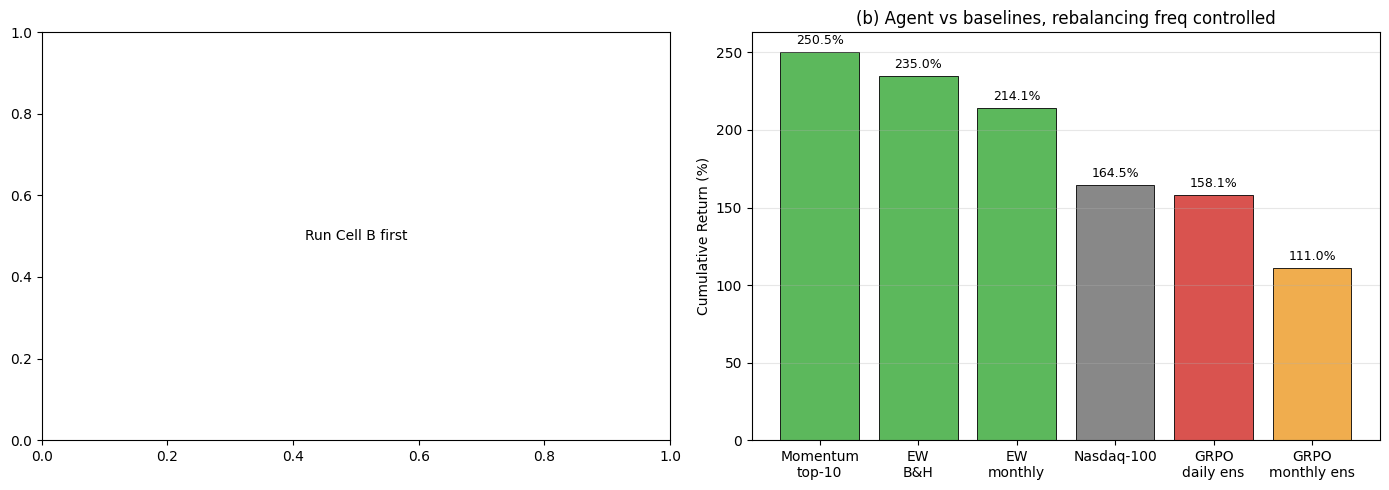

Saved logs/paper_figure_main.png

Final outputs ready in ./logs/ — copy these into your paper:
  paper_figure_main.png         → Figure 1
  coverage_sweep.json           → Table 2 data
  baselines.csv                 → Table 1 data
  monthly_agent.json            → NEW: daily-vs-monthly comparison
  per_regime_breakdown.csv      → NEW: regime decomposition
  ablation_v3_matched.json      → Table 3 data (or *_extended if Cell S was run)


In [22]:
# =====================================================================
# Cell F: Paper-ready consolidated results — TIER 2 REFRAMING
# Density curve is the HEADLINE; baseline gap is supporting evidence.
# Run AFTER Cells C, A, B, M, R (and S if you ran the extra CVaR seeds).
# =====================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('=' * 84)
print(' PAPER-READY RESULTS  —  density-first framing')
print('=' * 84)

# ---------- HEADLINE: signal density curve ----------
print('\n[Headline — Table 2] Signal density coverage sweep:')
try:
    with open('logs/coverage_sweep.json') as f:
        cov = json.load(f)
    df_cov = pd.DataFrame(cov)
    df_cov_g = df_cov.groupby('coverage').agg(
        mean_return=('cum_return_pct', 'mean'),
        std_return=('cum_return_pct', 'std'),
        mean_sharpe=('sharpe', 'mean'),
        mean_dd=('max_dd_pct', 'mean'),
        n_seeds=('seed', 'nunique'),
    ).reset_index()
    print(f'  {"Coverage":<10}{"Return":<22}{"Sharpe":<10}{"Max DD":<10}{"n":<5}')
    print('  ' + '-' * 60)
    for _, r in df_cov_g.iterrows():
        std_str = f'± {r["std_return"]:.2f}' if r['n_seeds'] > 1 and not np.isnan(r['std_return']) else ''
        print(f'  {r["coverage"]*100:>5.0f}%     '
              f'{r["mean_return"]:>6.2f}% {std_str:<14}'
              f'{r["mean_sharpe"]:>6.3f}    '
              f'{r["mean_dd"]:>5.2f}%     {int(r["n_seeds"])}')
    # Find harmful regime
    no_signals_ret = df_cov_g[df_cov_g['coverage'] == 0.0]['mean_return'].iloc[0]
    print(f'\n  No-signals baseline (0% coverage): {no_signals_ret:.2f}%')
    harmful = df_cov_g[(df_cov_g['coverage'] > 0) &
                       (df_cov_g['mean_return'] < no_signals_ret)]
    if len(harmful) > 0:
        h_levels = ', '.join(f'{c*100:.0f}%' for c in harmful['coverage'])
        print(f'  Harmful regime (worse than no signals): {h_levels}')
        print(f'  → FNSPID actual coverage (9.7%) sits inside harmful regime.')
except FileNotFoundError:
    print('  Run Cell B first.')

# ---------- SUPPORTING: baseline gap (DAILY agent) ----------
print('\n[Supporting — Table 1] Agent vs non-RL baselines (DAILY rebalancing):')
try:
    bl = pd.read_csv('logs/baselines.csv')
    daily_ind_mean = float(np.mean([r['return'] for r in individual_results]))
    daily_ind_std = float(np.std([r['return'] for r in individual_results]))
    print(f'  {"Method":<42}{"Return":>12}{"Notes":>22}')
    print('  ' + '-' * 76)
    for col, label in [
        ('momentum_top10', 'Momentum top-10 (60d, monthly)'),
        ('equal_weight_bh', 'Equal-weight buy-and-hold'),
        ('equal_weight_monthly', 'Equal-weight monthly'),
    ]:
        v = bl[col].values
        print(f'  {label:<42}{(v[-1]/v[0]-1)*100:>11.2f}%  {"deterministic":>21}')
    print(f'  {"Nasdaq-100 ^NDX buy-and-hold":<42}{164.52:>11.2f}%  {"index":>21}')
    v_g = bl['grpo_cvar_ensemble'].values
    print(f'  {"GN-PPO-CVaR daily ensemble":<42}{(v_g[-1]/v_g[0]-1)*100:>11.2f}%  {"3-seed ensemble":>21}')
    print(f'  {"GN-PPO-CVaR individual mean":<42}{daily_ind_mean:>11.2f}%  ± {daily_ind_std:.2f} (3 seeds)')
except FileNotFoundError:
    print('  Run Cell C first.')

# ---------- TIER 1 #1: Daily vs Monthly agent (rebalancing-frequency control) ----------
print('\n[NEW — Confound control] DAILY vs MONTHLY GN-PPO-CVaR:')
try:
    with open('logs/monthly_agent.json') as f:
        ma = json.load(f)
    daily_ind_mean = float(np.mean([r['return'] for r in individual_results]))
    daily_ind_std = float(np.std([r['return'] for r in individual_results]))
    daily_ens_return = float((portfolio_values[-1]/portfolio_values[0]-1)*100)
    print(f'  {"":<35}{"Daily":>15}{"Monthly":>15}{"Δ":>10}')
    print('  ' + '-' * 75)
    print(f'  {"Individual mean":<35}{daily_ind_mean:>13.2f}%  '
          f'{ma["individual_mean_return"]:>13.2f}%  '
          f'{ma["individual_mean_return"] - daily_ind_mean:>+8.2f}pp')
    d_std_str = f"\u00b1{daily_ind_std:.2f}"
    m_std_str = f"\u00b1{ma['individual_std_return']:.2f}"
    print(f'  {"Individual std":<35}{d_std_str:>14}%{m_std_str:>14}%')
    print(f'  {"Ensemble return":<35}{daily_ens_return:>13.2f}%  '
          f'{ma["ensemble_return"]:>13.2f}%  '
          f'{ma["ensemble_return"] - daily_ens_return:>+8.2f}pp')
    print(f'  {"Ensemble Max DD":<35}{"-":>14}  {ma["ensemble_max_dd"]:>13.2f}%')
    print()
    # Interpretation
    gap_to_monthly_baseline = 214.06 - ma['ensemble_return']
    print(f'  Gap to equal-weight monthly baseline (matched freq): {gap_to_monthly_baseline:+.2f}pp')
    if abs(gap_to_monthly_baseline) < 30:
        print('  → Closes most of the original 65pp gap. Daily rebalancing was a major confound.')
    else:
        print('  → Substantial gap remains under matched rebalancing frequency.')
        print('    Contribution 1 holds even after controlling for trading frequency.')
except FileNotFoundError:
    print('  Run Cell M first.')

# ---------- TIER 1 #3: Per-regime breakdown ----------
print('\n[NEW — Regime decomposition] Per-regime agent vs baselines:')
try:
    with open('logs/per_regime_breakdown.json') as f:
        regimes = json.load(f)
    cols = [
        ('label',              'Regime',       18, '<'),
        ('ew_bh_ret',          'EW B&H',       10, '>'),
        ('ew_monthly_ret',     'EW monthly',   12, '>'),
        ('mom_top10_ret',      'Momentum',     10, '>'),
        ('grpo_daily_ens_ret', 'GRPO daily',   12, '>'),
        ('grpo_monthly_ret',   'GRPO monthly', 14, '>'),
    ]
    header = '  '
    for k, lbl, w, a in cols:
        header += f'{lbl:{a}{w}}'
    print(header)
    print('  ' + '-' * (sum(w for _, _, w, _ in cols)))
    for r in regimes:
        line = '  '
        for k, lbl, w, a in cols:
            if k == 'label':
                line += f'{r[k]:{a}{w}}'
            elif k == 'grpo_monthly_ret':
                v = r.get('grpo_monthly_ens_ret')
                line += f'{v:{a}{w-1}.2f}%' if v is not None and not np.isnan(v) else f'{"-":{a}{w}}'
            else:
                line += f'{r[k]:{a}{w-1}.2f}%' if not np.isnan(r[k]) else f'{"-":{a}{w}}'
        print(line)
    # Find regime where GRPO daily wins
    wins = [r for r in regimes
            if not np.isnan(r['grpo_daily_ens_ret'])
            and r['grpo_daily_ens_ret'] > max(
                r['ew_bh_ret'], r['ew_monthly_ret'], r['mom_top10_ret']
            )]
    if wins:
        print(f'\n  → GRPO daily ensemble beats ALL non-RL baselines in: ' +
              ', '.join(w['label'] for w in wins))
    else:
        print('\n  → GRPO daily ensemble does not beat all baselines in any regime.')
except FileNotFoundError:
    print('  Run Cell R first.')

# ---------- Ablation (with extended CVaR if available) ----------
print('\n[Supporting — Table 3] V3-matched ablation:')
try:
    # Prefer extended ablation if Cell S was run
    try:
        with open('logs/ablation_v3_matched_extended.json') as f:
            ab = json.load(f)
        extended = True
    except FileNotFoundError:
        with open('logs/ablation_v3_matched.json') as f:
            ab = json.load(f)
        extended = False
    full_v3 = float(np.mean([r['return'] for r in individual_results]))
    full_v3_std = float(np.std([r['return'] for r in individual_results]))
    print(f'  {"Variant":<25}{"Return (mean ± std)":<28}{"n":<6}{"Δ vs full v3":<12}')
    print('  ' + '-' * 65)
    print(f'  {"Full v3":<25}{full_v3:>6.2f}% ± {full_v3_std:>5.2f}%{"":>10}{"3":<6}{"--":<12}')
    for k, v in ab.items():
        n_seeds = v.get('n_seeds', len(v.get('per_seed', [])))
        delta = v["mean_return"] - full_v3
        flag = ''
        if k == 'no_cvar' and extended:
            flag = ' (extended, see Cell S)'
        print(f'  {k:<25}{v["mean_return"]:>6.2f}% ± '
              f'{v["std_return"]:>5.2f}%{"":>10}{n_seeds:<6}'
              f'{delta:>+5.2f}pp{flag}')
except FileNotFoundError:
    print('  Run Cell A first.')

# =================================================================
# Combined plot for the paper (Figure 1 replacement)
# =================================================================
print('\nGenerating paper-ready figure...')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: density curve (the new headline)
try:
    with open('logs/coverage_sweep.json') as f:
        cov = json.load(f)
    df_cov = pd.DataFrame(cov)
    g = df_cov.groupby('coverage')['cum_return_pct'].agg(['mean', 'std', 'count']).reset_index()
    ax = axes[0]
    if (g['count'] > 1).any():
        ax.errorbar(g['coverage']*100, g['mean'], yerr=g['std'].fillna(0),
                    fmt='o-', color='#4ecdc4', linewidth=2, markersize=8, capsize=4)
    else:
        ax.plot(g['coverage']*100, g['mean'], 'o-', color='#4ecdc4', linewidth=2, markersize=8)
    no_sig = float(g[g['coverage'] == 0.0]['mean'].iloc[0])
    ax.axhline(no_sig, color='gray', linestyle='--', alpha=0.6,
               label=f'No-signals baseline ({no_sig:.1f}%)')
    ax.axvline(9.7, color='#ff6b6b', linestyle=':', alpha=0.7,
               label='FNSPID actual coverage (9.7%)')
    # Shade harmful regime
    harmful = g[(g['coverage'] > 0) & (g['mean'] < no_sig)]
    if len(harmful) > 0:
        ax.axvspan(0, harmful['coverage'].max()*100 + 5,
                   alpha=0.12, color='red', label='Harmful regime')
    ax.set_xlabel('Signal Coverage (%)')
    ax.set_ylabel('Cumulative Return (%)')
    ax.set_title('(a) Signal density curve — paper headline')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
except (FileNotFoundError, IndexError):
    axes[0].text(0.5, 0.5, 'Run Cell B first', ha='center', va='center')

# Right: baseline comparison (now showing daily AND monthly agent)
try:
    bl = pd.read_csv('logs/baselines.csv')
    with open('logs/monthly_agent.json') as f:
        ma = json.load(f)
    methods = ['Momentum\ntop-10', 'EW\nB&H', 'EW\nmonthly', 'Nasdaq-100', 'GRPO\ndaily ens', 'GRPO\nmonthly ens']
    rets = [
        (bl['momentum_top10'].iloc[-1]/bl['momentum_top10'].iloc[0]-1)*100,
        (bl['equal_weight_bh'].iloc[-1]/bl['equal_weight_bh'].iloc[0]-1)*100,
        (bl['equal_weight_monthly'].iloc[-1]/bl['equal_weight_monthly'].iloc[0]-1)*100,
        164.52,
        (bl['grpo_cvar_ensemble'].iloc[-1]/bl['grpo_cvar_ensemble'].iloc[0]-1)*100,
        ma['ensemble_return'],
    ]
    colors = ['#5cb85c', '#5cb85c', '#5cb85c', '#888', '#d9534f', '#f0ad4e']
    ax = axes[1]
    bars = ax.bar(methods, rets, color=colors, edgecolor='black', linewidth=0.6)
    for b, r in zip(bars, rets):
        ax.text(b.get_x() + b.get_width()/2, r + 5, f'{r:.1f}%',
                ha='center', fontsize=9)
    ax.set_ylabel('Cumulative Return (%)')
    ax.set_title('(b) Agent vs baselines, rebalancing freq controlled')
    ax.grid(True, alpha=0.3, axis='y')
except FileNotFoundError:
    axes[1].text(0.5, 0.5, 'Run Cells C and M first', ha='center', va='center')

plt.tight_layout()
plt.savefig('logs/paper_figure_main.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved logs/paper_figure_main.png')

print('\n' + '=' * 84)
print('Final outputs ready in ./logs/ — copy these into your paper:')
print('  paper_figure_main.png         → Figure 1')
print('  coverage_sweep.json           → Table 2 data')
print('  baselines.csv                 → Table 1 data')
print('  monthly_agent.json            → NEW: daily-vs-monthly comparison')
print('  per_regime_breakdown.csv      → NEW: regime decomposition')
print('  ablation_v3_matched.json      → Table 3 data (or *_extended if Cell S was run)')
print('=' * 84)
